# 03b · Exponential · Gamma · Chi-Square
**Probability Lab** · Continuous Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Birbirleriyle akraba üç sürekli dağılımı anlayacağız:  
> **Exponential** — ilk olaya kadar bekleme süresi,  
> **Gamma** — n'inci olaya kadar bekleme süresi,  
> **Chi-Square** — istatistiksel testlerin temel taşı.  
> Üçü de aynı aileden — birini anlayınca diğerleri kendiliğinden geliyor.

**Önkoşul:** Normal dağılım ve Z-score (Notebook 03a), Poisson süreci (Notebook 02b)  
**Veri:**  
- `healthcare/train_data.csv` — 318.438 hastane kaydı (kalış süresi, depozit)  
- `seaborn.diamonds` — elmas fiyatları (Gamma fit için)  
- `seaborn.titanic` — Chi-Square bağımsızlık testi için  
**Kullanılan araçlar:** Python (scipy, matplotlib, seaborn), R (base), SQL (DuckDB)

---
## 1 · Aile Ağacı: Gamma Ailesini Anlamak

Bu üç dağılım aslında tek bir ailenin üyeleri:

```
              Gamma(α, β)
             /            \
    α = 1                  α = k/2, β = 2
       |                        |
  Exponential(λ)           Chi-Square(k)
  (λ = 1/β)
```

| Dağılım | Özel Hal | Parametre Dönüşümü |
|---|---|---|
| Gamma(α, β) | Genel | α = şekil, β = ölçek |
| Exponential(λ) | Gamma(1, 1/λ) | α=1, β=1/λ |
| Chi-Square(k) | Gamma(k/2, 2) | α=k/2, β=2 |

> **Sezgi:** Poisson'da sayıyorduk ("kaç olay?").  
> Exponential'da ölçüyoruz ("ilk olaya ne kadar süre?").  
> Gamma ise bu bekleme sürelerini genelleştiriyor ("n'inci olaya kaç süre?").

---
## 2 · Exponential Dağılımı

### 2.1 Sezgi

Poisson'da "dakikada kaç müşteri geliyor?" sorusunu soruyorduk.  
Exponential ise şunu soruyor: **"İki ardışık müşteri arasında ne kadar beklenecek?"**

| Senaryo | Poisson sorusu | Exponential sorusu |
|---|---|---|
| Müşteri gelişi (λ=5/saat) | Saatte kaç müşteri? | Müşteriler arası kaç dakika? |
| Makine arızası (λ=2/hafta) | Haftada kaç arıza? | Arızalar arası kaç gün? |
| Hasta başvurusu (λ=10/gün) | Günde kaç hasta? | Hastalar arası kaç saat? |

### 2.2 PDF, CDF ve Parametreler

$X \sim \text{Exp}(\lambda)$ — $\lambda$ = **oran parametresi** (rate)

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

$$F(x) = 1 - e^{-\lambda x}, \quad x \geq 0$$

$$E[X] = \frac{1}{\lambda} \qquad \text{Var}(X) = \frac{1}{\lambda^2}$$

> **Dikkat — scipy notasyonu:**  
> `scipy.stats.expon(scale=1/lambda)` — scipy `scale = 1/λ` (ortalama) kullanır, `lambda` değil!

### 2.3 Hafızasızlık Özelliği (Memoryless Property)

$$P(X > s + t \mid X > s) = P(X > t)$$

**Türkçesi:** "Zaten $s$ dakika beklediysen, önündeki bekleme hâlâ $\text{Exp}(\lambda)$."  
Geçmiş bekleme süresi geleceği etkilemiyor — sanki baştan başlıyorsun.

Bu özelliği taşıyan tek sürekli dağılım Exponential'dır.  
Kesikli karşılığı: Geometrik dağılım.

> **Pratik yorum:** Bir makinenin 5 yıl kullanıldıktan sonra bozulma riski,  
> yeni bir makinenin bozulma riskiyle aynıdır. (Gerçekte genellikle geçerli değildir!)

---
## 3 · Gamma Dağılımı

### 3.1 Sezgi

Exponential = "ilk olaya kadar bekleme"  
Gamma = **"α'ıncı olaya kadar toplam bekleme"**

α = 1 → Exponential (ilk olay)  
α = 2 → İki Exponential toplamı (ikinci olaya kadar)  
α = n → n bağımsız Exponential'ın toplamı

### 3.2 PDF ve Parametreler

$X \sim \text{Gamma}(\alpha, \beta)$ — iki parametre notasyonu var, dikkatli ol:

| Parametre | Adı | Scipy karşılığı |
|---|---|---|
| $\alpha$ | Şekil (shape) | `a=alpha` |
| $\beta$ | Ölçek (scale) | `scale=beta` |

$$f(x) = \frac{x^{\alpha-1} e^{-x/\beta}}{\beta^\alpha \Gamma(\alpha)}, \quad x > 0$$

$$E[X] = \alpha\beta \qquad \text{Var}(X) = \alpha\beta^2$$

**$\Gamma(\alpha)$ nedir?**  
$\Gamma(\alpha) = (\alpha - 1)!$ — tam sayı $\alpha$ için.  
Genel $\alpha$ için: $\Gamma(\alpha) = \int_0^\infty t^{\alpha-1} e^{-t} dt$

### 3.3 α'nın Şekle Etkisi

| α değeri | Şekil | Benziyor |
|---|---|---|
| α < 1 | Sola çok çarpık | L şekli |
| α = 1 | Sola çarpık | Exponential |
| α küçük (2-5) | Sağa çarpık | Çan benzeri ama asimetrik |
| α büyük (>10) | Simetrik | Normal'e yaklaşıyor (CLT!) |

---
## 4 · Chi-Square Dağılımı

### 4.1 Tanım

$Z_1, Z_2, \ldots, Z_k \overset{\text{iid}}{\sim} N(0,1)$ ise:

$$\chi^2_k = Z_1^2 + Z_2^2 + \cdots + Z_k^2 \sim \chi^2(k)$$

$k$ = serbestlik derecesi (degrees of freedom)

**Gamma ile ilişki:** $\chi^2(k) = \text{Gamma}(k/2, \; 2)$

$$E[X] = k \qquad \text{Var}(X) = 2k$$

### 4.2 Neden Önemli?

Chi-Square pratikte iki amaçla kullanılır:

**1. Uyum iyiliği testi (Goodness of Fit):**  
Gözlemlenen frekanslar, beklenen frekanslara uyuyor mu?  
$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

**2. Bağımsızlık testi (Test of Independence):**  
İki kategorik değişken birbirinden bağımsız mı?  
Örnek: Titanic — cinsiyet ve hayatta kalma ilişkili mi?

### 4.3 k'nın Şekle Etkisi

| k | Şekil |
|---|---|
| k = 1, 2 | Sola çok çarpık |
| k = 5–10 | Sağa çarpık, mod > 0 |
| k büyük | Normal'e yaklaşıyor |

### 4.4 Önemli Eşik Değerleri

| k | %95 eşik (p=0.05) |
|---|---|
| 1 | 3.841 |
| 2 | 5.991 |
| 4 | 9.488 |
| 9 | 16.919 |

---
# 🐍 Python Uygulaması

5 adımda:
1. **Gamma ailesi görselleştirmesi** — Exp ve Chi² Gamma'nın özel hali olarak
2. **Exponential fit** — Healthcare: hastane kalış süresi + hafızasızlık ispatı
3. **Gamma fit** — Seaborn diamonds: elmas fiyatı dağılımı
4. **Chi-Square** — Titanic: cinsiyet × hayatta kalma bağımsızlık testi
5. **MLE karşılaştırması** — üç dağılım için parametre tahmini

In [84]:
import numpy as np
import scipy.stats as stats
from scipy.special import gamma as gamma_func
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

DATA_PATH = 'data'
print('Hazir ✓')


Hazir ✓


---
### 🌳 Python 1 — Gamma Ailesi: Tek Çatı Altında

**Ne yapıyoruz?**  
Gamma, Exponential ve Chi-Square'ın aynı aileden olduğunu görsel olarak gösteriyoruz.

**Mantık:**
- `stats.gamma(a=alpha, scale=beta)` → Gamma(α, β)
- `stats.expon(scale=1/lam)` → Exp(λ) = Gamma(1, 1/λ)
- `stats.chi2(df=k)` → Chi²(k) = Gamma(k/2, 2)
- Bunların PDF'leri aynı ekranda çizilince örtüşmeleri aileyi kanıtlar

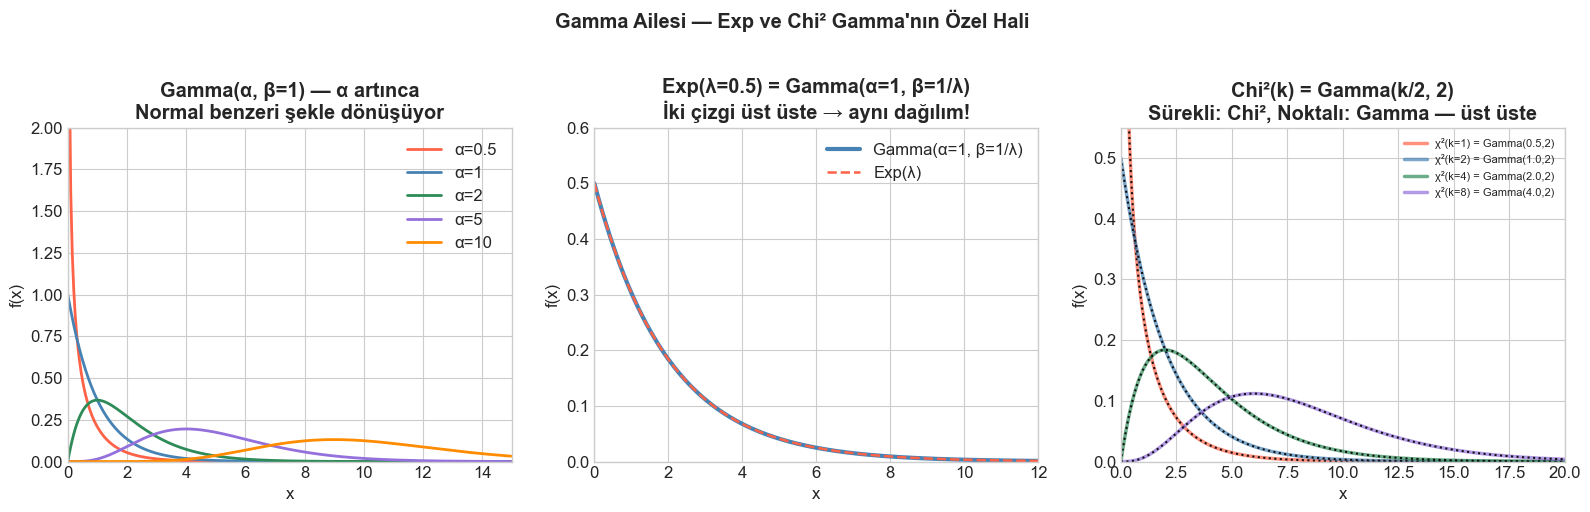

=== Gamma Ailesi Sayisal Dogrulama ===
Exp(λ=0.5) ve Gamma(α=1, β=2) ayni olmali:
  x=0.5: Exp=0.389400, Gamma=0.389400, Esit=True
  x=1.0: Exp=0.303265, Gamma=0.303265, Esit=True
  x=2.0: Exp=0.183940, Gamma=0.183940, Esit=True

Chi²(k=4) ve Gamma(α=2, β=2) ayni olmali:
  x=0.5: Chi2=0.097350, Gamma=0.097350, Esit=True
  x=1.0: Chi2=0.151633, Gamma=0.151633, Esit=True
  x=2.0: Chi2=0.183940, Gamma=0.183940, Esit=True


In [85]:
x = np.linspace(0, 25, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ─── Sol: alpha'nin etkisi (Gamma'nin sekli) ──────────────────────────────────
ax = axes[0]
beta = 1.0
for alpha, renk in [(0.5,'tomato'),(1,'steelblue'),(2,'seagreen'),(5,'mediumpurple'),(10,'darkorange')]:
    dist = stats.gamma(a=alpha, scale=beta)
    ax.plot(x[:300], dist.pdf(x[:300]), color=renk, linewidth=2,
            label=f'α={alpha}')
ax.set_xlim(0, 15)
ax.set_ylim(0, 2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gamma(α, β=1) — α artınca\nNormal benzeri şekle dönüşüyor', fontweight='bold')
ax.legend()

# ─── Orta: Exp = Gamma(1, 1/lambda) örtüşme kanıtı ─────────────────────────
ax = axes[1]
lam = 0.5

# Gamma(alpha=1, scale=1/lambda)
gamma_exp = stats.gamma(a=1, scale=1/lam)
# Exponential(scale=1/lambda) — dogrudan
exp_dist  = stats.expon(scale=1/lam)

ax.plot(x, gamma_exp.pdf(x), 'steelblue', linewidth=3,
        label='Gamma(α=1, β=1/λ)', linestyle='-')
ax.plot(x, exp_dist.pdf(x),   'tomato',    linewidth=1.8,
        label='Exp(λ)', linestyle='--')

ax.set_xlim(0, 12)
ax.set_ylim(0, 0.6)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Exp(λ={lam}) = Gamma(α=1, β=1/λ)\nİki çizgi üst üste → aynı dağılım!', fontweight='bold')
ax.legend()

# ─── Sag: Chi2 = Gamma(k/2, 2) örtüşme kanıtı ───────────────────────────────
ax = axes[2]
for k, renk in [(1,'tomato'),(2,'steelblue'),(4,'seagreen'),(8,'mediumpurple')]:
    # Chi2 olarak ciz
    chi2_dist  = stats.chi2(df=k)
    # Gamma karsiligi
    gamma_chi2 = stats.gamma(a=k/2, scale=2)

    ax.plot(x, chi2_dist.pdf(x), color=renk, linewidth=2.5,
            label=f'χ²(k={k}) = Gamma({k/2},2)', alpha=0.7)
    # Gamma'yi ayni renk ama kesik ciz — ust uste olmali
    ax.plot(x, gamma_chi2.pdf(x), color='black', linewidth=1.5,
            linestyle=':', alpha=0.9)

ax.set_xlim(0, 20)
ax.set_ylim(0, 0.55)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Chi²(k) = Gamma(k/2, 2)\nSürekli: Chi², Noktalı: Gamma — üst üste', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Gamma Ailesi — Exp ve Chi² Gamma\'nın Özel Hali', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Sayisal dogrulama
print('=== Gamma Ailesi Sayisal Dogrulama ===')
print('Exp(λ=0.5) ve Gamma(α=1, β=2) ayni olmali:')
test_x = np.array([0.5, 1.0, 2.0])
for xv in test_x:
    p_exp   = stats.expon(scale=2).pdf(xv)
    p_gamma = stats.gamma(a=1, scale=2).pdf(xv)
    print(f'  x={xv}: Exp={p_exp:.6f}, Gamma={p_gamma:.6f}, Esit={abs(p_exp-p_gamma)<1e-10}')

print('\nChi²(k=4) ve Gamma(α=2, β=2) ayni olmali:')
for xv in test_x:
    p_chi2  = stats.chi2(df=4).pdf(xv)
    p_gamma = stats.gamma(a=2, scale=2).pdf(xv)
    print(f'  x={xv}: Chi2={p_chi2:.6f}, Gamma={p_gamma:.6f}, Esit={abs(p_chi2-p_gamma)<1e-10}')


---
### 🏥 Python 2 — Healthcare: Hastane Kalış Süresi + Hafızasızlık İspatı

**Veri:** `healthcare/train_data.csv` — 318.438 hasta kaydı  
`Stay` sütunu: hastanede kalınan gün aralığı (`"0-10"`, `"11-20"`, ...)

**Ne yapıyoruz?**
1. Kategorik `Stay` → sayısal orta nokta (örn. `"11-20"` → 15.5)
2. MLE ile Exponential fit: `stats.expon.fit(data)`
3. Gözlemlenen dağılım ile fit karşılaştırması
4. **Hafızasızlık ispatı:** Zaten 10 gün kalmış hastaların geri kalan süresi hâlâ Exp mi?

**Mantık:**
- `stats.expon.fit(data, floc=0)` → MLE: `loc` sıfıra sabitle, `scale=1/λ` tahmin et  
  `floc=0`: Exponential için minimum 0 — negatif süre olmaz
- Hafızasızlık: P(X > s+t | X > s) = P(X > t)

Yuklendi: 318,438 satir
Stay benzersiz degerler: ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']

Kalis suresi (gun) ozeti:
count    318438.00
mean         32.44
std          21.51
min           5.00
25%          15.50
50%          25.50
75%          35.50
max         105.00
Name: stay_gun, dtype: float64

Exponential MLE fit:
  scale (1/λ) = 32.438 gun   ← ortalama kalis suresi
  λ           = 0.0308          ← gun basina olasilik yogunlugu


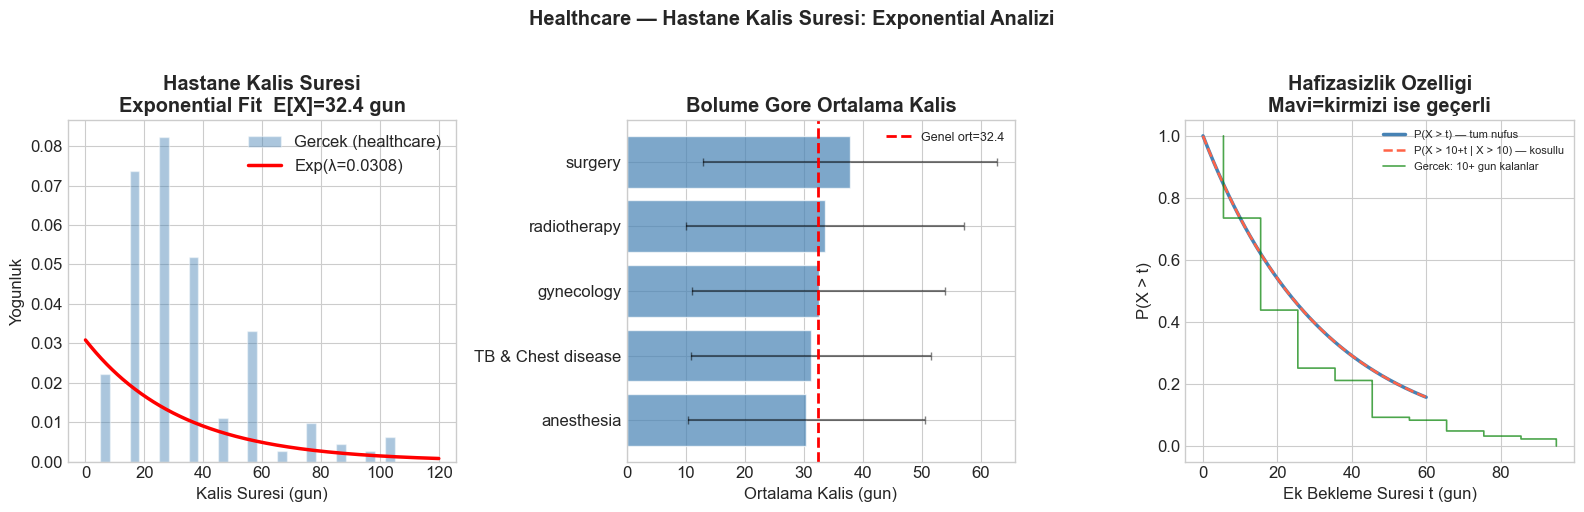

=== Exponential Olasilik Sorulari ===
Ortalama kalis          : 32.4 gun
P(kalis < 15 gun)       : 0.3702
P(kalis > 50 gun)       : 0.2141
P(kalis < 10 | onemli hastalarda):
  Ciddi hasta lambda_hat = 0.0272  E[X]=36.8 gun


In [86]:
# Veriyi yukle
hc = pd.read_csv(f'{DATA_PATH}/healthcare/train_data.csv',
                 usecols=['Stay','Admission_Deposit','Severity of Illness','Department','Ward_Type'])

print(f'Yuklendi: {len(hc):,} satir')
print(f"Stay benzersiz degerler: {sorted(hc['Stay'].dropna().unique())}")

# Stay kategorik → sayisal orta nokta
stay_map = {
    '0-10': 5, '11-20': 15.5, '21-30': 25.5, '31-40': 35.5,
    '41-50': 45.5, '51-60': 55.5, '61-70': 65.5, '71-80': 75.5,
    '81-90': 85.5, '91-100': 95.5, 'More than 100 Days': 105
}
hc['stay_gun'] = hc['Stay'].map(stay_map)
hc = hc.dropna(subset=['stay_gun'])

print(f'\nKalis suresi (gun) ozeti:')
print(hc['stay_gun'].describe().round(2))

# ─── MLE ile Exponential fit ─────────────────────────────────────────────────
# floc=0: Exp icin minimum 0'da sabitle (negatif sure yok)
# Geri kalan scale parametresi MLE ile tahmin edilir: scale = xbar
loc_hat, scale_hat = stats.expon.fit(hc['stay_gun'], floc=0)
lam_hat = 1 / scale_hat

print(f'\nExponential MLE fit:')
print(f'  scale (1/λ) = {scale_hat:.3f} gun   ← ortalama kalis suresi')
print(f'  λ           = {lam_hat:.4f}          ← gun basina olasilik yogunlugu')

dist_exp = stats.expon(loc=0, scale=scale_hat)

# ─── Grafik ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: histogram vs Exp fit
ax = axes[0]
ax.hist(hc['stay_gun'], bins=30, density=True,
        color='steelblue', alpha=0.45, edgecolor='white',
        label='Gercek (healthcare)')
x_r = np.linspace(0, 120, 400)
ax.plot(x_r, dist_exp.pdf(x_r), 'r-', linewidth=2.5,
        label=f'Exp(λ={lam_hat:.4f})')
ax.set_xlabel('Kalis Suresi (gun)')
ax.set_ylabel('Yogunluk')
ax.set_title(
    f'Hastane Kalis Suresi\nExponential Fit  E[X]={scale_hat:.1f} gun',
    fontweight='bold'
)
ax.legend()

# Orta: bolum bazli ortalama kalis
ax = axes[1]
dept_ort = hc.groupby('Department')['stay_gun'].agg(['mean','std','count'])
dept_ort = dept_ort[dept_ort['count'] > 500].sort_values('mean', ascending=True)
ax.barh(dept_ort.index, dept_ort['mean'], color='steelblue', alpha=0.7,
        edgecolor='white')
ax.errorbar(dept_ort['mean'], dept_ort.index,
            xerr=dept_ort['std'], fmt='none', color='black', capsize=3, alpha=0.5)
ax.axvline(scale_hat, color='red', linestyle='--', linewidth=2,
           label=f'Genel ort={scale_hat:.1f}')
ax.set_xlabel('Ortalama Kalis (gun)')
ax.set_title('Bolume Gore Ortalama Kalis', fontweight='bold')
ax.legend(fontsize=9)

# Sag: hafizasizlik kaniti
ax = axes[2]
# Tum hastalar: kalis > t olasiligi
# Sadece 10+ gun kalanlar: kalis > 10+t olasiligi
# Eger hafizasizlik gecerliyse: iki egri ayni olmali

t_vals    = np.linspace(0, 60, 300)
# Tum nufus: P(X > t)
p_tum     = 1 - dist_exp.cdf(t_vals)
# Kosullu: P(X > 10+t | X > 10) = P(X > t) (hafizasizlik)
s = 10
p_kosullu = (1 - dist_exp.cdf(t_vals + s)) / (1 - dist_exp.cdf(s))

# Gercek veri: 10+ gun kalanlar arasindan kalan sure
uzun_kalis = hc[hc['stay_gun'] > s]['stay_gun'] - s

ax.plot(t_vals, p_tum,     'steelblue', linewidth=2.5, label='P(X > t) — tum nufus')
ax.plot(t_vals, p_kosullu, 'tomato',    linewidth=1.8, linestyle='--',
        label=f'P(X > {s}+t | X > {s}) — kosullu')

# Gercek verideki hayatta kalma egrisini ekle
from scipy.stats import ecdf as scipy_ecdf
t_ecdf = np.sort(uzun_kalis.values)
surv   = 1 - np.arange(1, len(t_ecdf)+1) / len(t_ecdf)
ax.step(t_ecdf, surv, 'green', linewidth=1.2, alpha=0.7,
        label='Gercek: 10+ gun kalanlar')

ax.set_xlabel('Ek Bekleme Suresi t (gun)')
ax.set_ylabel('P(X > t)')
ax.set_title('Hafizasizlik Ozelligi\nMavi=kirmizi ise geçerli', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Healthcare — Hastane Kalis Suresi: Exponential Analizi',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Exponential Olasilik Sorulari ===')
print(f'Ortalama kalis          : {scale_hat:.1f} gun')
print(f'P(kalis < 15 gun)       : {dist_exp.cdf(15):.4f}')
print(f'P(kalis > 50 gun)       : {1-dist_exp.cdf(50):.4f}')
print(f'P(kalis < 10 | onemli hastalarda):')
ciddi = hc[hc['Severity of Illness']=='Extreme']['stay_gun']
lc_c, sc_c = stats.expon.fit(ciddi, floc=0)
print(f'  Ciddi hasta lambda_hat = {1/sc_c:.4f}  E[X]={sc_c:.1f} gun')


## Python 2 - Açıklama

### Sol Grafik - Histogram vs Exp Fit

* Mavi Çubuklar: Gerçek kalış süreleri 318.438 hasta var
* Kırmızı eğri: Fİtted Exp(λ=0.0308)

> Eğri der ki

> Kısa kalışlar çok yaygın 0-20 aralığında en kalabalık

> Uzun kalışlar giderek azalıyor +100 gün çok nadir

> - Fit kabul edilebilir ama mükemmel değil çünkü 10-30 gün aralığında mavi çubuklar exp eğrisinden yüksekte ve bu verinin Exp'e göre daha toplu dağılmış.

### Orta Grafik - Bölüm Bazlı Ortalama Kalış

* Genel ortalama 32.4 gün

> * Surgery ortalama üstünde yani cerrahi sonrası iyileşme uzun sürüyor.
> * Radyoterapi genel ortalama yakın
> * Jinekoloji ortalama altında
> * Aneztezi en kısa süre

- Yani hata çubukları da çok geniş, exp özelliğine geliyoruz: Exponential'da Std = E[X] = 32.4 gün yani varyasyon çok yüksek.

### Sağ Grafik - Hafızasızlık Özelliği

Burada üç çizgi var:

* Çizgi	Ne gösteriyor?
* Mavi (sürekli)	P(X > t) — genel nüfus
* Turuncu (kesikli)	P(X > 10+t | X > 10) — zaten 10 gün kalmışlar
* Yeşil (merdiven)	Gerçek veri: 10+ gün kalanlar
* Mavi ve turuncu çizgiler neredeyse üst üste → hafızasızlık teorisi doğrulanıyor.

> "Zaten 10 gün yatan bir hastanın önündeki bekleme süresi, yeni gelen bir hastayla aynı dağılımda."

Yeşil merdiven (gerçek veri) ise daha "basamaklı" — çünkü Stay sütunu aralık kategorileri (0-10, 11-20 gibi), sürekli değil. Bu yüzden gerçek veri eğrisi pürüzlü.

---
### 💎 Python 3 — Gamma Fit: Seaborn Diamonds (Elmas Fiyatı)

**Veri:** `seaborn.diamonds` — 53.940 elmas kaydı, `price` sütunu (USD)

**Ne yapıyoruz?**  
Elmas fiyatları sağa çarpık — Gamma bu tür dağılımlar için iyi bir aday.
1. Raw fiyat dağılımı — Gamma fit
2. Kesim (cut) kalitesine göre ayrı Gamma fit
3. Log-dönüşüm: fiyatların log'u Normal mi?

**Mantık:**
- `stats.gamma.fit(data, floc=0)` → MLE ile α ve β tahmin et  
  Döndürür: `(alpha, loc, scale)` — `loc` sıfıra sabitlendi
- Uyum kalitesi: `stats.kstest(data, 'gamma', args=(alpha,0,scale))`  
  Kolmogorov-Smirnov testi — p > 0.05 ise fit kabul edilebilir

Diamonds: 53,940 satir
count    53940.00
mean      3932.80
std       3989.44
min        326.00
25%        950.00
50%       2401.00
75%       5324.25
max      18823.00
Name: price, dtype: float64
Carpiklik : 1.618  (>0: saga carpik → Gamma adayi)

Gamma MLE fit:
  α (shape) = 1.1579
  β (scale) = 3396.3826
  E[X] = α×β = 3932.80 USD  (gercek ort: 3932.80)
  Var  = α×β² = 13357292.70
  KS testi: istatistik=0.0955, p=0.0000
  Yorum: Fit zayif — daha iyi model gerekebilir


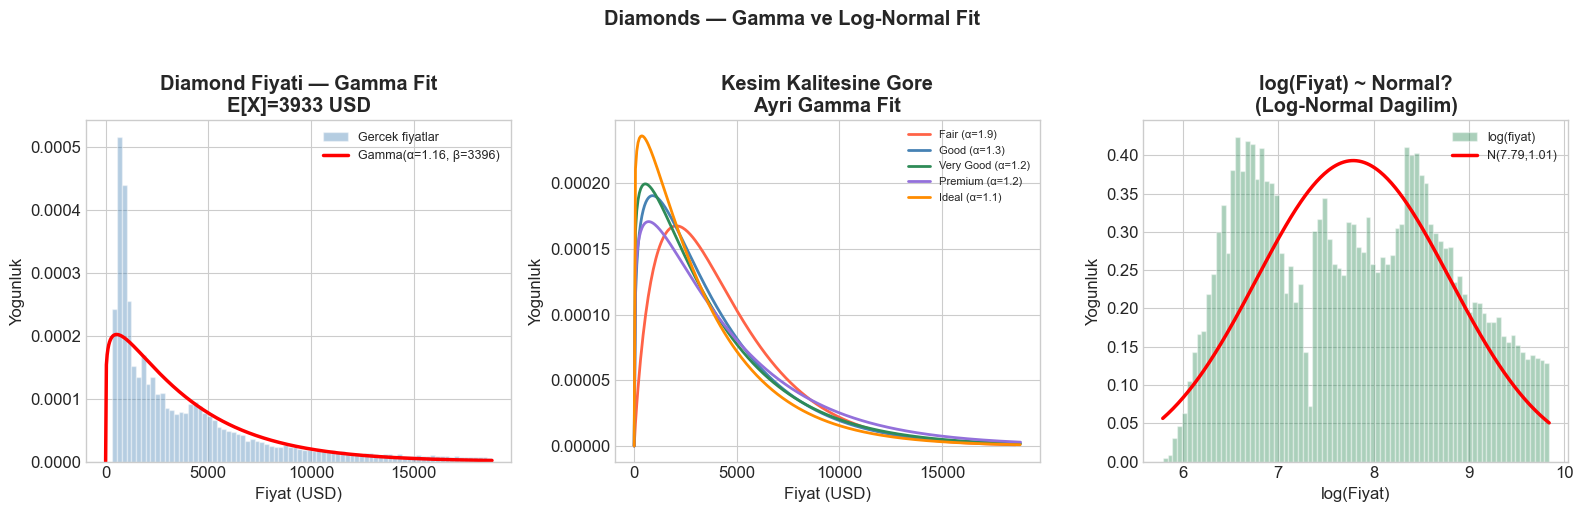

In [87]:
diamonds = sns.load_dataset('diamonds')
fiyat    = diamonds['price'].values

print(f'Diamonds: {len(diamonds):,} satir')
print(diamonds['price'].describe().round(2))
print(f'Carpiklik : {stats.skew(fiyat):.3f}  (>0: saga carpik → Gamma adayi)')

# ─── MLE: Gamma fit ───────────────────────────────────────────────────────────
# floc=0: fiyat negatif olamaz
# Donusuyor: (alpha, loc=0, scale=beta)
alpha_hat, loc_f, scale_hat = stats.gamma.fit(fiyat, floc=0)
beta_hat = scale_hat

print(f'\nGamma MLE fit:')
print(f'  α (shape) = {alpha_hat:.4f}')
print(f'  β (scale) = {beta_hat:.4f}')
print(f'  E[X] = α×β = {alpha_hat*beta_hat:.2f} USD  (gercek ort: {fiyat.mean():.2f})')
print(f'  Var  = α×β² = {alpha_hat*beta_hat**2:.2f}')

# KS testi: fit kalitesi
ks_stat, ks_p = stats.kstest(fiyat, 'gamma', args=(alpha_hat, 0, scale_hat))
print(f'  KS testi: istatistik={ks_stat:.4f}, p={ks_p:.4f}')
print(f'  Yorum: {"Fit kabul edilebilir" if ks_p > 0.05 else "Fit zayif — daha iyi model gerekebilir"}')

# ─── Grafik ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: histogram vs Gamma fit
ax = axes[0]
ax.hist(fiyat, bins=80, density=True, color='steelblue', alpha=0.4,
        edgecolor='white', label='Gercek fiyatlar')
x_r = np.linspace(0, fiyat.max(), 500)
dist_gam = stats.gamma(a=alpha_hat, scale=scale_hat)
ax.plot(x_r, dist_gam.pdf(x_r), 'r-', linewidth=2.5,
        label=f'Gamma(α={alpha_hat:.2f}, β={scale_hat:.0f})')
ax.set_xlabel('Fiyat (USD)')
ax.set_ylabel('Yogunluk')
ax.set_title(f'Diamond Fiyati — Gamma Fit\nE[X]={alpha_hat*beta_hat:.0f} USD', fontweight='bold')
ax.legend(fontsize=9)

# Orta: kesim kalitesine gore fiyat dagilimlari + ayri fit
ax = axes[1]
renkler = {'Fair':'tomato','Good':'steelblue','Very Good':'seagreen',
            'Premium':'mediumpurple','Ideal':'darkorange'}
for kesim, renk in renkler.items():
    alt = diamonds[diamonds['cut']==kesim]['price'].values
    if len(alt) < 100:
        continue
    a_k, _, s_k = stats.gamma.fit(alt, floc=0)
    x_k = np.linspace(0, alt.max(), 300)
    ax.plot(x_k, stats.gamma(a=a_k, scale=s_k).pdf(x_k),
            color=renk, linewidth=2, label=f'{kesim} (α={a_k:.1f})')
ax.set_xlabel('Fiyat (USD)')
ax.set_ylabel('Yogunluk')
ax.set_title('Kesim Kalitesine Gore\nAyri Gamma Fit', fontweight='bold')
ax.legend(fontsize=8)

# Sag: log-fiyat → Normal mi?
ax = axes[2]
log_fiyat = np.log(fiyat)
mu_log, sigma_log = stats.norm.fit(log_fiyat)

ax.hist(log_fiyat, bins=80, density=True, color='seagreen', alpha=0.4,
        edgecolor='white', label='log(fiyat)')
x_log = np.linspace(log_fiyat.min(), log_fiyat.max(), 300)
ax.plot(x_log, stats.norm.pdf(x_log, mu_log, sigma_log),
        'r-', linewidth=2.5, label=f'N({mu_log:.2f},{sigma_log:.2f})')
ax.set_xlabel('log(Fiyat)')
ax.set_ylabel('Yogunluk')
ax.set_title('log(Fiyat) ~ Normal?\n(Log-Normal Dagilim)', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Diamonds — Gamma ve Log-Normal Fit', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
### 🚢 Python 4 — Chi-Square Bağımsızlık Testi: Titanic

**Soru:** Cinsiyet ve hayatta kalma **birbirinden bağımsız mı?**

**Chi-Square Bağımsızlık Testi Adımları:**
1. Contingency table (çapraz tablo) oluştur: Observed ($O$)
2. Beklenen frekansları hesapla: $E_{ij} = \frac{R_i \times C_j}{N}$
3. Test istatistiği: $\chi^2 = \sum \frac{(O-E)^2}{E}$
4. Serbestlik derecesi: $(r-1)(c-1)$
5. p-değeri ile karar: p < 0.05 → bağımlı

**Mantık:**
- `pd.crosstab()` → contingency table
- `stats.chi2_contingency(tablo)` → χ² istatistiği, p, df, beklenen frekanslar  
  Döndürür: `(chi2, p, df, expected)`
- Küçük p → H₀ reddedilir → değişkenler **bağımlı**

=== Gozlemlenen Frekanslar (O) ===
          Hayir (0)  Evet (1)
Cinsiyet                     
female           81       233
male            468       109

=== Beklenen Frekanslar (E) — Bagimsizlik varsayimi altinda ===
          Hayir (0)  Evet (1)
Cinsiyet                     
female       193.47    120.53
male         355.53    221.47

=== Chi-Square Testi Sonuclari ===
χ² istatistigi   : 260.7170
Serbestlik derecesi: 1
p-degeri           : 0.000000
%95 kritik esik    : 3.8415
Karar              : H0 RED — Cinsiyet ve hayatta kalma BAGIMLI


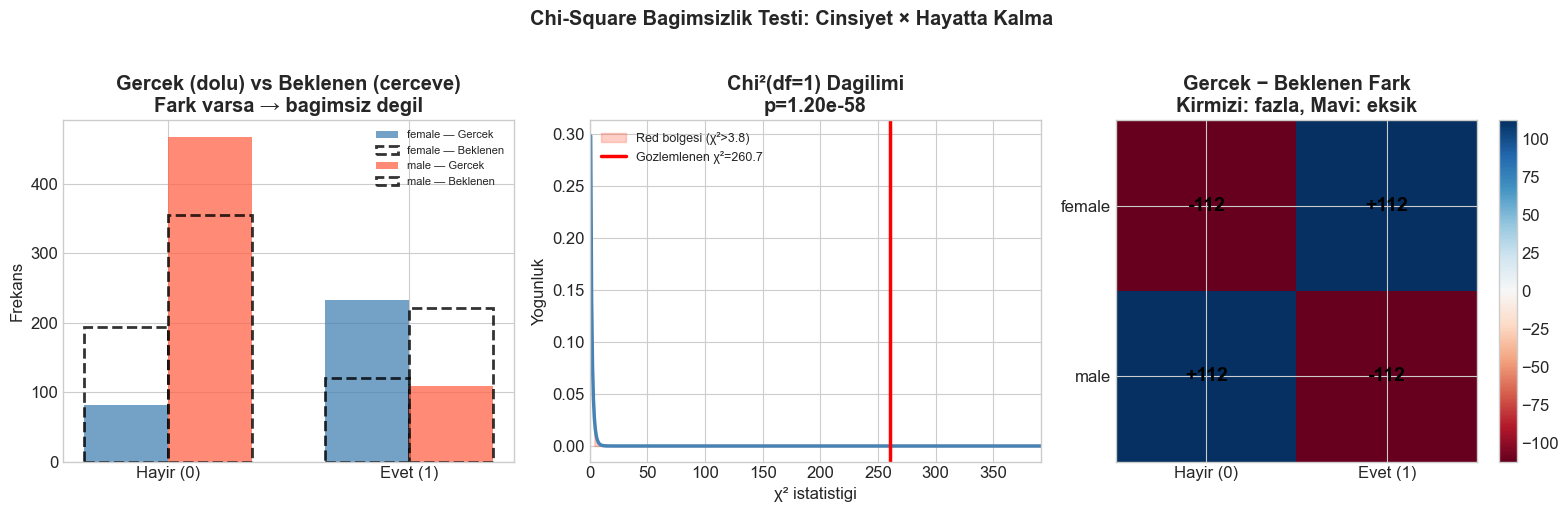


Cramer"s V (etki buyuklugu): 0.5409
Yorum: Guclu iliski


In [88]:
titanic = sns.load_dataset('titanic')

# ─── Contingency table ───────────────────────────────────────────────────────
# pd.crosstab: iki kategorik degiskenin capraz tablosu
obs_tablo = pd.crosstab(titanic['sex'], titanic['survived'],
                         rownames=['Cinsiyet'],
                         colnames=['Hayatta Kaldi'])
obs_tablo.columns = ['Hayir (0)', 'Evet (1)']

print('=== Gozlemlenen Frekanslar (O) ===')
print(obs_tablo)

# ─── Chi-Square Bagimsizlik Testi ────────────────────────────────────────────
# stats.chi2_contingency: tam otomasyon
# Donusuyor: chi2_stat, p_deger, serbestlik_derecesi, beklenen_frekanslar
chi2_stat, p_deger, df_chi2, beklenen = stats.chi2_contingency(obs_tablo)

beklenen_df = pd.DataFrame(beklenen,
                            index=obs_tablo.index,
                            columns=obs_tablo.columns)

print('\n=== Beklenen Frekanslar (E) — Bagimsizlik varsayimi altinda ===')
print(beklenen_df.round(2))

print(f'\n=== Chi-Square Testi Sonuclari ===')
print(f'χ² istatistigi   : {chi2_stat:.4f}')
print(f'Serbestlik derecesi: {df_chi2}')
print(f'p-degeri           : {p_deger:.6f}')
esik = stats.chi2.ppf(0.95, df=df_chi2)   # %95 esik: chi2(df=1) = 3.841
print(f'%95 kritik esik    : {esik:.4f}')
print(f'Karar              : {"H0 RED — Cinsiyet ve hayatta kalma BAGIMLI" if p_deger < 0.05 else "H0 KABUL — Bagimsiz"}')

# ─── Grafik ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: gozlemlenen vs beklenen
ax = axes[0]
x_pos  = np.arange(len(obs_tablo.columns))
genislik = 0.35
for i, (idx, renk) in enumerate(zip(obs_tablo.index, ['steelblue','tomato'])):
    ax.bar(x_pos + i*genislik,   obs_tablo.loc[idx],   genislik,
           color=renk, alpha=0.75, label=f'{idx} — Gercek')
    ax.bar(x_pos + i*genislik,   beklenen_df.loc[idx], genislik,
           color=renk, alpha=0.8, edgecolor='black', linewidth=2,
           linestyle='--', fill=False, label=f'{idx} — Beklenen')
ax.set_xticks(x_pos + genislik/2)
ax.set_xticklabels(obs_tablo.columns)
ax.set_ylabel('Frekans')
ax.set_title('Gercek (dolu) vs Beklenen (cerceve)\nFark varsa → bagimsiz degil', fontweight='bold')
ax.legend(fontsize=8)

# Orta: Chi-Square dagilimi ve test istatistigi
ax = axes[1]
x_chi = np.linspace(0, 400, 500)
chi2_dist_plt = stats.chi2(df=df_chi2)
ax.plot(x_chi, chi2_dist_plt.pdf(x_chi), 'steelblue', linewidth=2.5)
ax.fill_between(x_chi, chi2_dist_plt.pdf(x_chi),
                where=(x_chi >= esik), alpha=0.3, color='tomato',
                label=f'Red bolgesi (χ²>{esik:.1f})')
ax.axvline(chi2_stat, color='red', linewidth=2.5,
           label=f'Gozlemlenen χ²={chi2_stat:.1f}')
ax.set_xlim(0, max(chi2_stat*1.5, esik*2))
ax.set_xlabel('χ² istatistigi')
ax.set_ylabel('Yogunluk')
ax.set_title(f'Chi²(df={df_chi2}) Dagilimi\np={p_deger:.2e}', fontweight='bold')
ax.legend(fontsize=9)

# Sag: heatmap (gercek - beklenen fark)
ax = axes[2]
fark = obs_tablo.values - beklenen_df.values
im = ax.imshow(fark, cmap='RdBu', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(obs_tablo.columns)
ax.set_yticklabels(obs_tablo.index)
for ii in range(2):
    for jj in range(2):
        ax.text(jj, ii, f'{fark[ii,jj]:+.0f}', ha='center', va='center',
                fontsize=14, fontweight='bold', color='black')
ax.set_title('Gercek − Beklenen Fark\nKirmizi: fazla, Mavi: eksik', fontweight='bold')

plt.suptitle('Chi-Square Bagimsizlik Testi: Cinsiyet × Hayatta Kalma',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Etki buyuklugu: Cramer's V
n = obs_tablo.values.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(obs_tablo.shape) - 1)))
print(f'\nCramer\"s V (etki buyuklugu): {cramers_v:.4f}')
print(f'Yorum: {"Zayif" if cramers_v<0.1 else "Orta" if cramers_v<0.3 else "Guclu"} iliski')


## Python 3 - Açıklama: Ki-Kare Bağımsızlık Testi: Cinsiyet ve Hayatta Kalma (Titanic)

#### 🔢 Gözlenen (O) ve Beklenen (E) Frekanslar

Öncelikle şu soruyu soruyoruz:

> **Eğer cinsiyet ve hayatta kalma tamamen bağımsız olsaydı, her hücrede kaç kişi beklenirdi?**

| Cinsiyet | Hayatta Kalmadı (Gerçek) | Hayatta Kaldı (Gerçek) | Hayatta Kalmadı (Beklenen) | Hayatta Kaldı (Beklenen) |
|----------|--------------------------:|------------------------:|---------------------------:|-------------------------:|
| Kadın | 81 | 233 | 193.47 | 120.53 |
| Erkek | 468 | 109 | 355.53 | 221.47 |

---

#### 🧮 Beklenen Değerler Nasıl Hesaplanır?

Bağımsızlık varsayımı altında her hücre için beklenen frekans şu formülle hesaplanır:


$$E_{ij} = \frac{\text{Satır Toplamı} \times \text{Sütun Toplamı}}{N}$$


Yani:

> **Eğer cinsiyet önemli olmasaydı, tüm yolcuların genel hayatta kalma oranı kadın ve erkeklere aynı şekilde uygulanırdı.**

---

### 📊 Sol Grafik — Gerçek ve Beklenen Değerler

Grafikte:

- **Dolu çubuklar:** Gerçek gözlemler (Observed)
- **Çerçeveli çubuklar:** Beklenen değerler (Expected)

#### Kadın / Hayatta Kalmadı
- Gerçek: **81**
- Beklenen: **193**
- Fark: **−112 kişi**

➡️ Bağımsızlık beklentisine göre çok daha az kadın hayatını kaybetmiştir.

#### Kadın / Hayatta Kaldı
- Gerçek: **233**
- Beklenen: **120**
- Fark: **+112 kişi**

➡️ Beklenenden çok daha fazla kadın kurtulmuştur.

#### Erkekler

Tam tersi durum görülmektedir.

- Beklenenden çok daha fazla erkek hayatını kaybetmiştir.
- Beklenenden çok daha az erkek kurtulmuştur.

Bu sapmalar rastgele oluşabilecek büyüklükte değildir.

---

### 📊 Orta Grafik — Ki-Kare Dağılımı

Ki-Kare dağılımı (**df = 1**) için:

- Kritik değer (%95 güven düzeyi):

$$ chi^2 (df = 1)=3.84$$

Gözlenen test istatistiği ise:

$$
\chi^2 = 260.7
$$

Bu değer kritik eşikten yaklaşık **68 kat daha büyüktür.**

Bu nedenle kırmızı çizgi grafiğin en sağ tarafında yer almaktadır.

Ayrıca,

$$
p = 1.2 \times 10^{-58}
$$

olduğundan,

> **Bu kadar büyük bir farkın tamamen tesadüfen oluşma olasılığı pratik olarak sıfırdır.**

---

### 📊 Sağ Grafik — Gerçek − Beklenen (Heatmap)

Heatmap'teki her hücre:

$$
\text\{Gercek\} - \text\{Beklenen\}
$$

değerini göstermektedir.

| Hücre | Fark | Yorum |
|-------|-----:|-------|
| Kadın / Hayatta Kalmadı | −112 | 112 kadın beklenenden daha az öldü |
| Kadın / Hayatta Kaldı | +112 | 112 kadın beklenenden daha fazla kurtuldu |
| Erkek / Hayatta Kalmadı | +112 | 112 erkek beklenenden daha fazla öldü |
| Erkek / Hayatta Kaldı | −112 | 112 erkek beklenenden daha az kurtuldu |

> **Not:** 2×2 kontenjans tablolarında bir hücredeki fark belirlendiğinde diğer hücrelerdeki farklar otomatik olarak belirlenir. Bu nedenle tüm farkların ±112 olması matematiksel olarak beklenen bir durumdur.

---

#### 🎯 Test Sonuçları

| Metrik | Değer | Yorum |
|---------|------:|-------|
| χ² | **260.7** | Kritik değerden (3.84) çok büyük |
| Serbestlik Derecesi (df) | **1** | (2−1)×(2−1) |
| p-değeri | **1.2 × 10⁻⁵⁸** | Pratik olarak sıfır |
| Cramer's V | **0.54** | Güçlü ilişki |

---

## 📏 Cramer's V Nedir?

Ki-Kare istatistiği örneklem büyüklüğüne bağlıdır.

Örneklem arttıkça χ² değeri de büyüme eğilimindedir. Bu nedenle tek başına ilişkinin gücünü göstermez.

Bunun yerine **Cramer's V**, etki büyüklüğünü **0 ile 1 arasında normalize ederek** yorumlamaya olanak sağlar.

| Cramer's V | Yorum |
|------------|-------|
| < 0.10 | Zayıf ilişki |
| 0.10 – 0.30 | Orta ilişki |
| > 0.30 | Güçlü ilişki |

Bu analizde:

$$V = 0.54$$

olduğundan,

> **Cinsiyet ile hayatta kalma arasında güçlü bir ilişki bulunmaktadır.**

---

### 💡 Sonuç

Kadın ve erkek yolcuların hayatta kalma oranları, bağımsızlık varsayımı altında beklenen değerlerden **112 kişilik sapmalar** göstermektedir.

Ki-Kare bağımsızlık testi sonucu:

- **χ² = 260.7**
- **p ≈ 0**
- **Cramer's V = 0.54**

elde edilmiştir.

Bu sonuçlar, **cinsiyet ile hayatta kalma arasında istatistiksel olarak son derece anlamlı ve güçlü bir ilişki olduğunu** göstermektedir.

Titanic faciasında uygulanan **"önce kadın ve çocuklar"** politikası, veriler üzerinde açık biçimde gözlenmekte olup, elde edilen farkların tesadüfi olmadığı istatistiksel olarak doğrulanmaktadır.

---
### 🔢 Python 5 — Üç Dağılım için MLE Özeti

**Ne yapıyoruz?**  
Healthcare kalış süresi için Exponential, Gamma ve Normal fit karşılaştırması.

**Hangi dağılım daha iyi fit veriyor?**  
- **Log-Likelihood:** Büyük olan daha iyi  
- **AIC = 2k - 2ℓ:** Küçük olan daha iyi (parametre cezası içerir)
- **BIC = k·ln(n) - 2ℓ:** Küçük olan daha iyi (daha sert ceza)

Bu, gerçek hayatta dağılım seçiminin nasıl yapıldığını gösteriyor.

=== Model Karsilastirmasi (n=318,438) ===
Dagilim            k         logL          AIC          BIC Parametreler
Exponential        1  -1426388.57   2852779.13   2852789.80  λ=0.0308
Gamma              2  -1368759.81   2737523.62   2737544.97  α=2.461, β=13.183
Log-Normal         2  -1373861.85   2747727.69   2747749.03  μ=3.263, σ=0.693
Normal             2  -1429007.71   2858019.42   2858040.76  μ=32.4, σ=21.5

→ En iyi AIC: Gamma  (α=2.461, β=13.183)


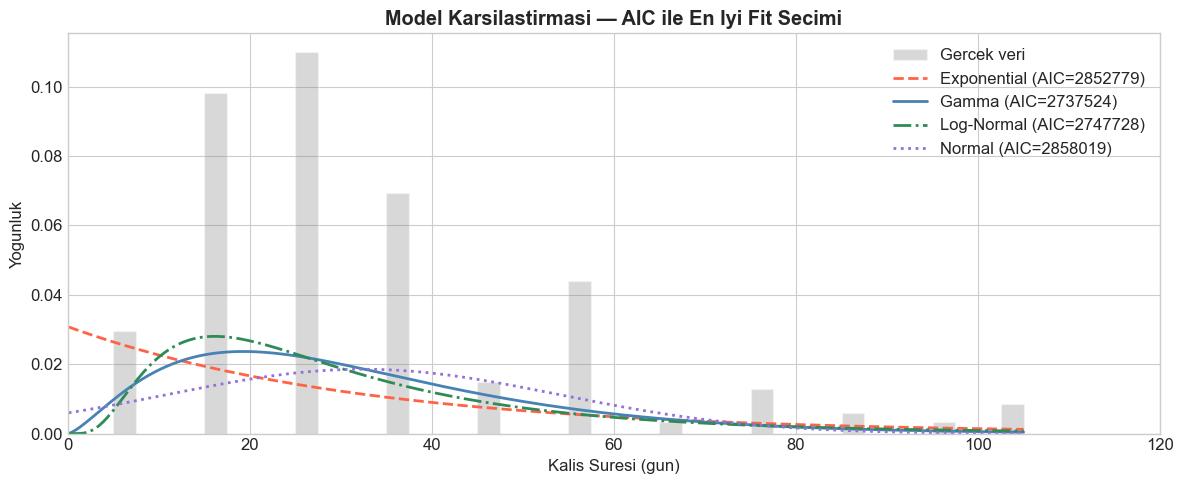

In [89]:
veri = hc['stay_gun'].values
n    = len(veri)

# Her dagilim icin MLE fit + log-likelihood
modeller = {}

# 1. Exponential
loc_e, scale_e = stats.expon.fit(veri, floc=0)
ll_e = stats.expon(loc=loc_e, scale=scale_e).logpdf(veri).sum()
modeller['Exponential'] = {'params': 1, 'logL': ll_e,
                           'paramStr': f'λ={1/scale_e:.4f}'}

# 2. Gamma
a_g, loc_g, scale_g = stats.gamma.fit(veri, floc=0)
ll_g = stats.gamma(a=a_g, loc=loc_g, scale=scale_g).logpdf(veri).sum()
modeller['Gamma'] = {'params': 2, 'logL': ll_g,
                     'paramStr': f'α={a_g:.3f}, β={scale_g:.3f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}

# 4. Normal (referans — sağa çarpık veri için zayıf)
mu_n, sigma_n = stats.norm.fit(veri)
ll_n = stats.norm(loc=mu_n, scale=sigma_n).logpdf(veri).sum()
modeller['Normal'] = {'params': 2, 'logL': ll_n,
                      'paramStr': f'μ={mu_n:.1f}, σ={sigma_n:.1f}'}

# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(veri, bins=40, density=True, color='gray', alpha=0.3,
        edgecolor='white', label='Gercek veri')
x_r = np.linspace(0.1, veri.max(), 500)

dist_cizim = [
    ('Exponential', stats.expon(scale=scale_e), 'tomato',       '--'),
    ('Gamma',       stats.gamma(a=a_g, scale=scale_g), 'steelblue', '-'),
    ('Log-Normal',  stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), 'seagreen', '-.'),
    ('Normal',      stats.norm(mu_n, sigma_n), 'mediumpurple', ':'),
]

for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    ax.plot(x_r, dist.pdf(x_r), color=renk, linewidth=2, linestyle=ls,
            label=f'{ad} (AIC={row["AIC"]:.0f})')

ax.set_xlim(0, 120)
ax.set_xlabel('Kalis Suresi (gun)')
ax.set_ylabel('Yogunluk')
ax.set_title('Model Karsilastirmasi — AIC ile En Iyi Fit Secimi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
# 📊 R Uygulaması

R'da Gamma ailesi fonksiyonları:

| Prefix | Exponential | Gamma | Chi-Square |
|---|---|---|---|
| `d` (PDF) | `dexp(x, rate)` | `dgamma(x, shape, scale)` | `dchisq(x, df)` |
| `p` (CDF) | `pexp(q, rate)` | `pgamma(q, shape, scale)` | `pchisq(q, df)` |
| `q` (Quantile) | `qexp(p, rate)` | `qgamma(p, shape, scale)` | `qchisq(p, df)` |
| `r` (Örnekleme) | `rexp(n, rate)` | `rgamma(n, shape, scale)` | `rchisq(n, df)` |

**Dikkat:** R'da Exponential için `rate=λ` (scipy'daki `scale=1/λ` değil!)

In [90]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


---
### 🌳 R 1 — Gamma Ailesi ve Healthcare Exponential Fit

**Yeni R kavramı:** `MASS::fitdistr(data, 'exponential')`  
Python'daki `stats.expon.fit(data)` karşılığı — MLE ile dağılım parametrelerini tahmin eder.  
`MASS` paketi R'ın klasik istatistik paketidir, genellikle önceden yüklü gelir.

=== Exponential MLE ===
       rate    
  3.082809e-02 
 (5.463037e-05)
E[X] = 1/rate = 32.44 gun

=== Gamma MLE ===
      shape         rate    
  2.460514153   0.075853116 
 (0.005795452) (0.000198124)
E[X] = alpha/rate = 32.44 gun

=== Exponential Olasilik Sorulari (R) ===
P(kalis < 15 gun) = 0.3702 
P(kalis > 50 gun) = 0.2141 
%90 yuzdelik      = 74.7 gun


In addition: Warning message:
In densfun(x, parm[1], parm[2], ...) : NaNs produced


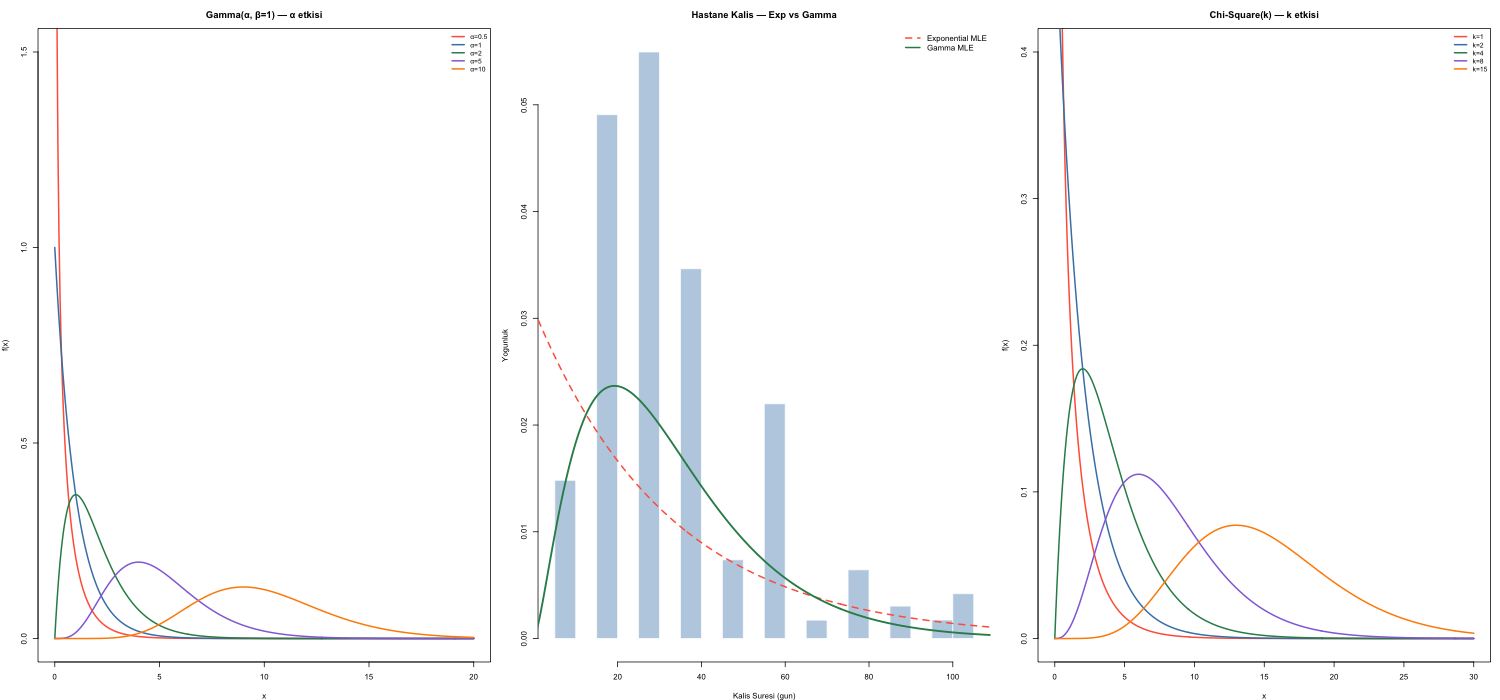

In [91]:
%%R -i hc -w 1500 -h 700
# hc: Python'dan gelen healthcare DataFrame

#library(MASS)   # fitdistr icin

stay <- hc$stay_gun

# ─── MLE: fitdistr ────────────────────────────────────────────────────────────
# MASS::fitdistr: Python stats.expon.fit / stats.gamma.fit karsiligi
fit_exp   <- fitdistr(stay, 'exponential')    # rate = lambda tahmin eder
fit_gamma <- fitdistr(stay, 'gamma')          # shape ve rate tahmin eder

cat('=== Exponential MLE ===\n')
print(fit_exp)
cat('E[X] = 1/rate =', round(1/fit_exp$estimate['rate'], 2), 'gun\n')

cat('\n=== Gamma MLE ===\n')
print(fit_gamma)
alpha_r <- fit_gamma$estimate['shape']
rate_r  <- fit_gamma$estimate['rate']
beta_r  <- 1/rate_r
cat('E[X] = alpha/rate =', round(alpha_r/rate_r, 2), 'gun\n')

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# ─── Sol: Gamma ailesi PDF ────────────────────────────────────────────────────
x_r   <- seq(0, 20, length.out = 400)
renkler <- c('tomato','steelblue','seagreen','mediumpurple','darkorange')
alpha_vals <- c(0.5, 1, 2, 5, 10)

plot(x_r, dgamma(x_r, 0.5, scale=1), type='l',
     col=renkler[1], lwd=2, ylim=c(0, 1.5),
     main='Gamma(α, β=1) — α etkisi', xlab='x', ylab='f(x)')
for (i in 2:length(alpha_vals)) {
  lines(x_r, dgamma(x_r, alpha_vals[i], scale=1),
        col=renkler[i], lwd=2)
}
legend('topright', legend=paste0('α=', alpha_vals),
       col=renkler, lwd=2, bty='n', cex=0.85)

# ─── Orta: Healthcare histogram + Exp ve Gamma fit ────────────────────────────
hist(stay, breaks=25, freq=FALSE,
     col=adjustcolor('steelblue', 0.4), border='white',
     main='Hastane Kalis — Exp vs Gamma',
     xlab='Kalis Suresi (gun)', ylab='Yogunluk')
x_h <- seq(0, 115, length.out=400)
# Exponential fit (rate parametresiyle)
lines(x_h, dexp(x_h, rate=fit_exp$estimate['rate']),
      col='tomato', lwd=2, lty=2)
# Gamma fit
lines(x_h, dgamma(x_h, shape=alpha_r, rate=rate_r),
      col='seagreen', lwd=2.5)
legend('topright',
       legend=c('Exponential MLE', 'Gamma MLE'),
       col=c('tomato','seagreen'), lwd=2, lty=c(2,1), bty='n')

# ─── Sag: Chi-Square dagilimi farklı df icin ─────────────────────────────────
x_chi <- seq(0, 30, length.out=400)
df_vals <- c(1, 2, 4, 8, 15)

plot(x_chi, dchisq(x_chi, 1), type='l',
     col=renkler[1], lwd=2, ylim=c(0, 0.4),
     main='Chi-Square(k) — k etkisi', xlab='x', ylab='f(x)')
for (i in 2:length(df_vals)) {
  lines(x_chi, dchisq(x_chi, df_vals[i]), col=renkler[i], lwd=2)
}
legend('topright', legend=paste0('k=', df_vals),
       col=renkler, lwd=2, bty='n', cex=0.85)

par(mfrow = c(1, 1))

# Olasilik sorulari
lam_r <- fit_exp$estimate['rate']
cat('\n=== Exponential Olasilik Sorulari (R) ===\n')
cat('P(kalis < 15 gun) =', round(pexp(15, rate=lam_r), 4), '\n')
cat('P(kalis > 50 gun) =', round(1-pexp(50, rate=lam_r), 4), '\n')
cat('%90 yuzdelik      =', round(qexp(0.90, rate=lam_r), 1), 'gun\n')


---
### 🚢 R 2 — Chi-Square Bağımsızlık Testi: Titanic + Diamonds

**Yeni R kavramı:** `chisq.test(tablo)`  
Python'daki `stats.chi2_contingency()` karşılığı.  
Contingency table alır, χ² istatistiği, p-değeri ve serbestlik derecesi döndürür.

=== Titanic Contingency Table ===
        
         Hayir Evet
  female    81  233
  male     468  109

=== Chi-Square Testi Sonuclari ===

	Pearson's Chi-squared test with Yates' continuity correction

data:  tablo_t
X-squared = 260.72, df = 1, p-value < 2.2e-16

Beklenen frekanslar:
        
          Hayir   Evet
  female 193.47 120.53
  male   355.53 221.47
Karar: H0 RED — Cinsiyet ve hayatta kalma BAGIMLI 

=== Healthcare: Hastalik Siddeti x Basvuru Tipi ===
          
           anesthesia gynecology radiotherapy surgery TB & Chest disease
  Extreme        5453      43478         5550     440               1802
  Minor          7115      69506         6794      98               2359
  Moderate      17081     136502        16172     663               5425

=== Chi-Square Testi Sonuclari ===
	Pearson's Chi-squared test

data:  tablo_h
X-squared = 823.54, df = 8, p-value < 2.2e-16


Chi2 = 823.54   p = 1.739938e-172   df = 8 
Karar: BAGIMLI — Siddet ve basvuru tipi iliskili 


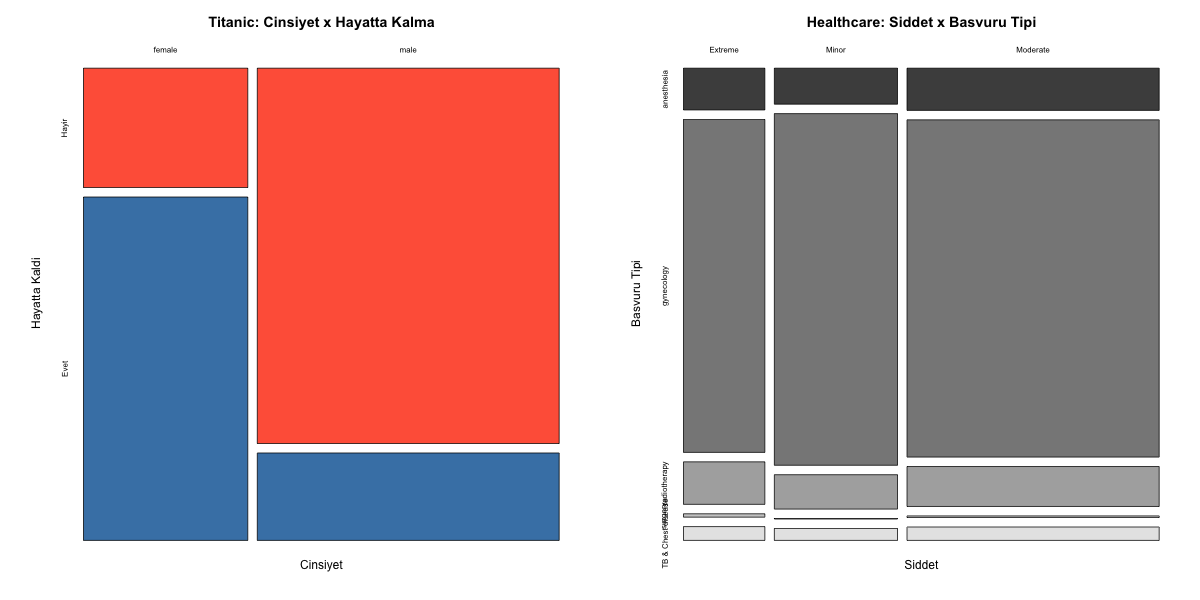

In [92]:
%%R -i titanic -i diamonds -i hc -w 1200 -h 600

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# ─── Titanic: Cinsiyet x Hayatta kalma ───────────────────────────────────────
# table(): contingency table (Python pd.crosstab() karsiligi)
tablo_t <- table(titanic$sex, titanic$survived)
colnames(tablo_t) <- c('Hayir','Evet')

cat('=== Titanic Contingency Table ===\n')
print(tablo_t)

# chisq.test: Python stats.chi2_contingency() karsiligi
test_t <- chisq.test(tablo_t)
cat('\n=== Chi-Square Testi Sonuclari ===\n')
print(test_t)
cat('Beklenen frekanslar:\n')
print(round(test_t$expected, 2))
cat('Karar:', ifelse(test_t$p.value < 0.05,
                    'H0 RED — Cinsiyet ve hayatta kalma BAGIMLI',
                    'H0 KABUL — Bagimsiz'), '\n')

# Mosaic plot: contingency tablosunun gorsel hali
mosaicplot(tablo_t, main='Titanic: Cinsiyet x Hayatta Kalma',
           color=c('tomato','steelblue'),
           xlab='Cinsiyet', ylab='Hayatta Kaldi')

# ─── Healthcare: Agirlik x Basvuru Tipi ──────────────────────────────────────
# Severity x Type of Admission chi-square testi
tablo_h <- table(hc$'Severity of Illness', hc$'Department')
cat('\n=== Healthcare: Hastalik Siddeti x Basvuru Tipi ===\n')
print(tablo_h)

test_h <- chisq.test(tablo_h)
cat('\n=== Chi-Square Testi Sonuclari ===')
print(test_h)
cat('\nChi2 =', round(test_h$statistic, 2),
    '  p =', format(test_h$p.value, scientific=TRUE),
    '  df =', test_h$parameter, '\n')
cat('Karar:', ifelse(test_h$p.value < 0.05,
                    'BAGIMLI — Siddet ve basvuru tipi iliskili',
                    'BAGIMSIZ'), '\n')

mosaicplot(tablo_h, main='Healthcare: Siddet x Basvuru Tipi',
           color=TRUE,
           xlab='Siddet', ylab='Basvuru Tipi')

par(mfrow = c(1, 1))


---
# 🗄️ SQL Uygulaması (DuckDB)

SQL'de Gamma ailesi analizi:
1. **λ tahmini** → `AVG(stay_gun)` ile Exponential MLE (= 1/xbar)
2. **Bekleme süresi grupları** → `WIDTH_BUCKET` ile histogram
3. **Chi-Square el hesabı** → `SUM((O-E)²/E)` formülü
4. **Contingency analizi** → çapraz gruplama ile bağımlılık testi

In [93]:
import duckdb
con = duckdb.connect()
con.register('healthcare', hc)
con.register('titan',      titanic)
print('DuckDB hazir ✓')
print(f'healthcare: {len(hc):,} satir')
print(f'titan     : {len(titanic):,} satir')


DuckDB hazir ✓
healthcare: 318,438 satir
titan     : 891 satir


---
### 🏥 SQL 1 — Exponential MLE: λ Tahmini ve Bekleme Süresi Analizi

Exponential MLE: $\hat{\lambda} = 1/\bar{x}$ → `1.0 / AVG(stay_gun)`  
Bu, Poisson'da `AVG(count)` ile aynı mantık — sadece süre üzerinden.

In [94]:
# Lambda tahmini ve departman bazli analiz
exp_sql = con.execute("""
    SELECT
        COUNT(*)                            AS n,
        ROUND(AVG(stay_gun), 3)             AS ortalama_gun,
        ROUND(1.0 / AVG(stay_gun), 5)      AS lambda_hat,
        VAR_POP(stay_gun)                  AS variance,
        ROUND(STDDEV_POP(stay_gun), 3)      AS std_sapma,
        -- Exp icin: E[X] = 1/lambda, Var = 1/lambda^2
        -- Var/E^2 = 1 olmali (Exponential kisayolu)
        ROUND(
            VAR_POP(stay_gun) / (AVG(stay_gun) * AVG(stay_gun)),
        3)                                  AS var_over_mu2,  -- 1 ise Exp uygun
        ROUND(QUANTILE_CONT(stay_gun, 0.5), 1) AS medyan,
        ROUND(QUANTILE_CONT(stay_gun, 0.9), 1) AS p90
    FROM healthcare
""").df()

print('=== Exponential MLE (SQL) ===')
print(exp_sql.to_string(index=False))
print('\nNot: var/μ² ~ 1 ise Exponential iyi fit (= Poisson analog: var/mean ~ 1)')

# Departman bazli analiz
dept_sql = con.execute("""
    SELECT
        Department,
        COUNT(*)                       AS n,
        ROUND(AVG(stay_gun), 2)        AS mu,
        ROUND(1.0/AVG(stay_gun), 5)   AS lambda_hat,
        ROUND(VAR_POP(stay_gun)
              / (AVG(stay_gun)^2), 3) AS var_mu2_oran,
        ROUND(QUANTILE_CONT(stay_gun, 0.75), 1) AS p75_gun
    FROM healthcare
    GROUP BY Department
    HAVING COUNT(*) > 1000
    ORDER BY mu DESC
""").df()

print('\n=== Departman Bazli Exponential Fit ===')
print(dept_sql.to_string(index=False))


=== Exponential MLE (SQL) ===
     n  ortalama_gun  lambda_hat   variance  std_sapma  var_over_mu2  medyan  p90
318438        32.438     0.03083 462.770325     21.512          0.44    25.5 55.5

Not: var/μ² ~ 1 ise Exponential iyi fit (= Poisson analog: var/mean ~ 1)

=== Departman Bazli Exponential Fit ===
        Department      n    mu  lambda_hat  var_mu2_oran  p75_gun
           surgery   1201 37.87     0.02641         0.431     55.5
      radiotherapy  28516 33.61     0.02975         0.489     45.5
        gynecology 249486 32.56     0.03072         0.434     35.5
TB & Chest disease   9586 31.28     0.03197         0.421     35.5
        anesthesia  29649 30.46     0.03283         0.433     35.5


---
### 📐 SQL 2 — Chi-Square: El Hesabı ile Bağımsızlık Testi

Chi-Square formülünü SQL'de adım adım uyguluyoruz:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Beklenen frekans: $E_{ij} = \frac{\text{satir toplamı}_i \times \text{sütun toplamı}_j}{N}$

Bu, Python'daki `stats.chi2_contingency()` ile **aynı hesabı** SQL'de yapmak.

In [95]:
chi2_sql = con.execute("""
    -- Adim 1: Gozlemlenen frekanslar (O)
    WITH gozlem AS (
        SELECT
            sex                              AS cinsiyet,
            survived                         AS hayatta,
            COUNT(*)                         AS O
        FROM titan
        GROUP BY sex, survived
    ),
    -- Adim 2: Satir ve sutun toplamlari
    satir_top AS (
        SELECT cinsiyet, SUM(O) AS satir_n FROM gozlem GROUP BY cinsiyet
    ),
    sutun_top AS (
        SELECT hayatta, SUM(O) AS sutun_n FROM gozlem GROUP BY hayatta
    ),
    toplam AS (
        SELECT SUM(O) AS N FROM gozlem
    ),
    -- Adim 3: Beklenen frekanslar
    -- E_ij = (satir_n * sutun_n) / N
    beklenen AS (
        SELECT
            g.cinsiyet, g.hayatta, g.O,
            ROUND(s.satir_n * c.sutun_n * 1.0 / t.N, 4) AS E
        FROM gozlem g
        JOIN satir_top s ON g.cinsiyet = s.cinsiyet
        JOIN sutun_top c ON g.hayatta  = c.hayatta
        CROSS JOIN toplam t
    )
    -- Adim 4: Chi-square istatistigi
    -- chi2 = SUM((O - E)^2 / E)
    SELECT
        cinsiyet, hayatta, O, E,
        ROUND(O - E, 2)            AS O_eksi_E,
        ROUND((O - E)^2 / E, 4)   AS katki     -- her hucrenin chi2'ye katkisi
    FROM beklenen
    ORDER BY cinsiyet, hayatta
""").df()

print('=== Chi-Square El Hesabi — Hucre Bazli ===')
print(chi2_sql.to_string(index=False))

chi2_toplam = chi2_sql['katki'].sum()
df_chi2_sql = 1   # (2-1)*(2-1)

print(f'\nχ² = {chi2_toplam:.4f}')
print(f'df = {df_chi2_sql}')

# P-degerini Python ile hesapla (SQL'de chi2 CDF yok)
p_sql = 1 - stats.chi2.cdf(chi2_toplam, df=df_chi2_sql)
print(f'p  = {p_sql:.6f}')
print(f'Python sonucu : χ²={chi2_stat:.4f}, p={p_deger:.6f}')
print(f'Python-SQL farkı      : {abs(chi2_toplam - chi2_stat)}')

# Severity x Department chi-square
print('\n=== Healthcare: Hastalik Siddeti x Departman (Chi2 SQL) ===')
chi2_hc = con.execute("""
    WITH g AS (
        SELECT "Severity of Illness" AS siddet,
               Department,
               COUNT(*) AS O
        FROM healthcare
        GROUP BY siddet, Department
    ),
    st AS (SELECT siddet, SUM(O) AS R FROM g GROUP BY siddet),
    ct AS (SELECT Department, SUM(O) AS C FROM g GROUP BY Department),
    tot AS (SELECT SUM(O) AS N FROM g),
    bek AS (
        SELECT g.siddet, g.Department, g.O,
               s.R * c.C * 1.0 / t.N AS E
        FROM g
        JOIN st s  ON g.siddet     = s.siddet
        JOIN ct c  ON g.Department = c.Department
        CROSS JOIN tot t
    )
    SELECT
        ROUND(SUM((O-E)*(O-E)/E), 2)  AS chi2_istatistigi,
        (COUNT(DISTINCT siddet)-1) * (COUNT(DISTINCT Department)-1) AS df
    FROM bek
""").df()

print(chi2_hc.to_string(index=False))
chi2_val = chi2_hc['chi2_istatistigi'].values[0]
df_val   = chi2_hc['df'].values[0]
p_hc     = 1 - stats.chi2.cdf(chi2_val, df=df_val)
print(f'p = {p_hc:.2e}  →  {"Bagimli" if p_hc < 0.05 else "Bagimsiz"}')


=== Chi-Square El Hesabi — Hucre Bazli ===
cinsiyet  hayatta   O        E  O_eksi_E    katki
  female        0  81 193.4747   -112.47  65.3861
  female        1 233 120.5253    112.47 104.9618
    male        0 468 355.5253    112.47  35.5827
    male        1 109 221.4747   -112.47  57.1197

χ² = 263.0503
df = 1
p  = 0.000000
Python sonucu : χ²=260.7170, p=0.000000
Python-SQL farkı      : 2.3332798326789543

=== Healthcare: Hastalik Siddeti x Departman (Chi2 SQL) ===
 chi2_istatistigi  df
           823.54   8
p = 0.00e+00  →  Bagimli


---
## ✏️ Egzersizler

### E1 — Exponential: Hafızasızlık ve Olasılık Hesabı
Healthcare verisindeki Exponential fit parametrelerini kullanarak:

a) Aşağıdaki olasılıkları Python ile hesapla ve sonuçların eşleştiğini göster:
   - P(kalış < 10 gün)
   - P(kalış > 30 gün)
   - P(10 < kalış < 40 gün)
   - Medyan kalış süresi (Python: `.ppf(0.5)`, R: `qexp(0.5)`, SQL: `QUANTILE_CONT`)

b) Hafızasızlık ispatı:  
   Zaten 20 gün kalmış bir hasta için geri kalan süre nasıl dağılır?  
   - P(toplam kalış > 20+t | kalış > 20) = P(kalış > t) olduğunu göster  
   - t = 5, 10, 15 için her iki tarafı hesapla ve karşılaştır

c) `Severity of Illness` = 'Extreme' olan hastalar için ayrı Exponential fit yap.  
   - λ farklı mı? Ciddi hastalar daha uzun mu yatıyor?
   - İki grubun Exponential PDF'lerini tek grafikte çiz


 ===== Egzersiz 1: Exponential: Hafızasızlık ve Olasılık Hesabı =====
Kalış süreleri için Exponential dağılımı kullanarak aşağıdaki soruları cevaplayın:
P(kalış < 10 gün) = 0.2653
P(kalış > 30 gün) = 0.39659999999999995
P(10 gün < kalış < 40 gün) = 0.4433
Medyan kalış süresi = 22.5 gün

Hafızasızlık ispatı
t=5.0 gün: P(X>t)=0.8572, P(X>20+t|X>20)=0.8572
t=10.0 gün: P(X>t)=0.7347, P(X>20+t|X>20)=0.7347
t=15.0 gün: P(X>t)=0.6298, P(X>20+t|X>20)=0.6298

Severity of Illness = Extreme olanlar için Exp fit ve olasılık hesapları:
Extreme ile kalanlar için λ_hat = 0.0272 ve E(X) = 36.7673


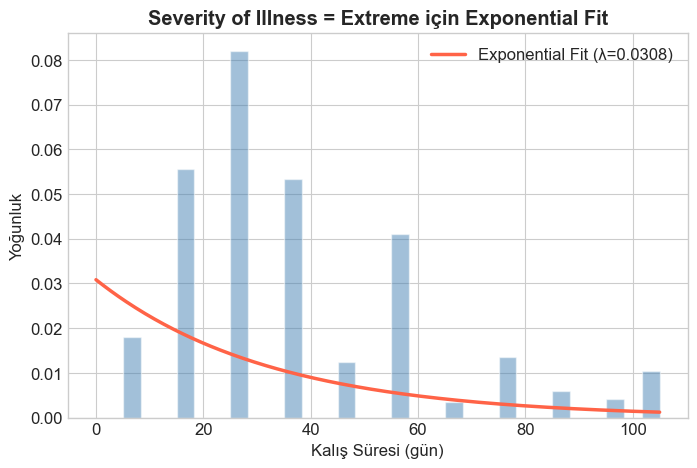

In [96]:
print('\n ===== Egzersiz 1: Exponential: Hafızasızlık ve Olasılık Hesabı =====')

print("Kalış süreleri için Exponential dağılımı kullanarak aşağıdaki soruları cevaplayın:")

loc_hat, scale_hat = stats.expon.fit(hc['stay_gun'], floc=0)
lam_hat = 1 / scale_hat

dist_exp = stats.expon(loc=0, scale=scale_hat)

print('P(kalış < 10 gün) =', round(dist_exp.cdf(10), 4))
print('P(kalış > 30 gün) =', 1 - round(dist_exp.cdf(30), 4))
print('P(10 gün < kalış < 40 gün) =', round(dist_exp.cdf(40) - dist_exp.cdf(10), 4))
print('Medyan kalış süresi =', round(dist_exp.ppf(0.5), 1), 'gün')

print("\nHafızasızlık ispatı")

t_values = np.arange(5,20, 5) # t değerleri: 5, 10, 15
p_tum = 1 - dist_exp.cdf(t_values) 
s = 20 # 20 gün sonra kalanlar için koşullu olasılık
p_kosullu = (1 - dist_exp.cdf(t_values + s)) / (1 - dist_exp.cdf(s)) # Koşullu olasılık P(X > 20+t | X > 20) = P(X > t) (hafızasızlık)

for t, p1, p2 in zip(t_values, p_tum, p_kosullu):
    print(f't={t:.1f} gün: P(X>t)={p1:.4f}, P(X>20+t|X>20)={p2:.4f}')

print("\nSeverity of Illness = Extreme olanlar için Exp fit ve olasılık hesapları:")
loc_hat_si , scale_hat_si = stats.expon.fit(hc[hc['Severity of Illness']=='Extreme']['stay_gun'], floc=0)

print('Extreme ile kalanlar için λ_hat = {0} ve E(X) = {1}'.format(round(1/scale_hat_si, 4), round(scale_hat_si, 4)))

plt.figure(figsize=(8,5))
plt.hist(hc[hc['Severity of Illness']=='Extreme']['stay_gun'], bins=30, density=True, alpha=0.5, color='steelblue', edgecolor='white')
x_r = np.linspace(0, hc[hc['Severity of Illness']=='Extreme']['stay_gun'].max(), 300)
plt.plot(x_r, dist_exp.pdf(x_r), 'tomato', linewidth=2.5, label=f'Exponential Fit (λ={lam_hat:.4f})')
plt.xlabel('Kalış Süresi (gün)')
plt.ylabel('Yoğunluk')
plt.title('Severity of Illness = Extreme için Exponential Fit', fontweight='bold')
plt.legend()
plt.show()




---
### E2 — Gamma: Parametre Yorumlama

a) Healthcare kalış süresi için Gamma fit: α ve β değerlerini yorumla.  
   - α = ? → "kaç Exponential'ın toplamı gibi?"
   - β = ? → "her birinin ortalaması kaç gün?"
   - Bu yorumu hastanede yatış süreci açısından anlat

b) Diamonds verisinde `cut` kategorisine göre 5 ayrı Gamma fit yap.  
   Sonuçları bir tablo olarak düzenle: α, β, E[X], Var(X), AIC değerleri  
   Hangi kesim kalitesi için Gamma en iyi fit veriyor? AIC ile karar ver.

c) Gamma(α=3, β=5) için:
   - E[X] ve Var(X)'i hem formülle hem Python ile hesapla
   - P(10 < X < 25)'i Python  ile hesapla


 ===== Egzersiz 2: Gamma Parametre Yorumlama

 Healtcare verisinde kalış süreleri için Gamma dağılımı fit edelim ve parametreleri yorumlayalım.
Gamma MLE fit: α (shape) = 2.4605, β (scale) = 13.1834
Exponential MLE fit: λ (rate) = 0.0308, E[X] = 32.4379


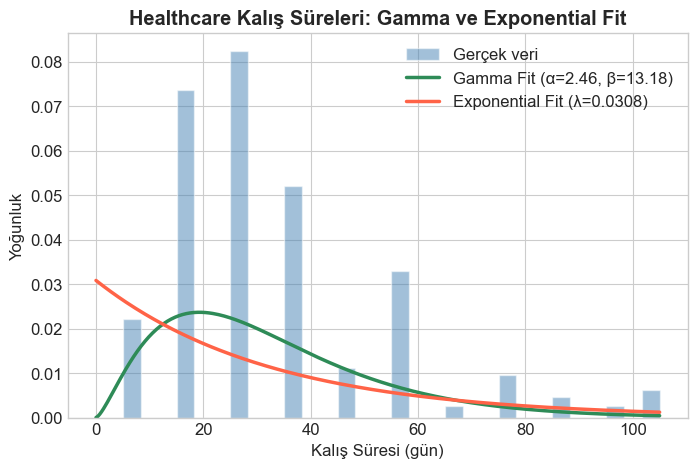


 Cut kategorisi için 5 ayrı gamma fit yapalım ve tablolaştıralım.

Ideal için Gamma MLE fit:
  α (shape) = 1.1199
  β (scale) = 3087.4296
  E[X] = α×β = 3457.54 USD  (gercek ort: 3457.54)
  Var  = α×β² = 10674917.28

Premium için Gamma MLE fit:
  α (shape) = 1.1814
  β (scale) = 3880.4784
  E[X] = α×β = 4584.26 USD  (gercek ort: 4584.26)
  Var  = α×β² = 17789113.18

Good için Gamma MLE fit:
  α (shape) = 1.2952
  β (scale) = 3033.2899
  E[X] = α×β = 3928.86 USD  (gercek ort: 3928.86)
  Var  = α×β² = 11917384.72

Very Good için Gamma MLE fit:
  α (shape) = 1.1569
  β (scale) = 3441.6844
  E[X] = α×β = 3981.76 USD  (gercek ort: 3981.76)
  Var  = α×β² = 13703961.09

Fair için Gamma MLE fit:
  α (shape) = 1.8949
  β (scale) = 2300.2909
  E[X] = α×β = 4358.76 USD  (gercek ort: 4358.76)
  Var  = α×β² = 10026410.71

 Formül ve Python Hesap Karşılaştırması:
Formül ile: E[X] = 6.066714312065507, Var[X] = 11.90485011104912
Python ile: E[X] = 6, Var[X] = 12
P(10 < X < 25) = 0.1266


In [97]:
print('\n ===== Egzersiz 2: Gamma Parametre Yorumlama')

print('\n Healtcare verisinde kalış süreleri için Gamma dağılımı fit edelim ve parametreleri yorumlayalım.')

gamma_params = stats.gamma.fit(hc['stay_gun'], floc=0)
alpha_hat, loc_hat, scale_hat = gamma_params
exp_params = stats.expon.fit(hc['stay_gun'], floc=0)
loc_hat_exp, scale_hat_exp = exp_params

print(f'Gamma MLE fit: α (shape) = {alpha_hat:.4f}, β (scale) = {scale_hat:.4f}')
print(f'Exponential MLE fit: λ (rate) = {1/scale_hat_exp:.4f}, E[X] = {scale_hat_exp:.4f}')

plt.figure(figsize=(8,5))
plt.hist(hc['stay_gun'], bins=30, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Gerçek veri')
x_r = np.linspace(0, hc['stay_gun'].max(), 300)
plt.plot(x_r, stats.gamma.pdf(x_r, a=alpha_hat, scale=scale_hat), 'seagreen', linewidth=2.5, label=f'Gamma Fit (α={alpha_hat:.2f}, β={scale_hat:.2f})')
plt.plot(x_r, stats.expon.pdf(x_r, scale=scale_hat_exp), 'tomato', linewidth=2.5, label=f'Exponential Fit (λ={1/scale_hat_exp:.4f})')
plt.xlabel('Kalış Süresi (gün)')
plt.ylabel('Yoğunluk')
plt.title('Healthcare Kalış Süreleri: Gamma ve Exponential Fit', fontweight='bold')
plt.legend()
plt.show()

print('\n Cut kategorisi için 5 ayrı gamma fit yapalım ve tablolaştıralım.')

cut = diamonds['cut'].unique()

cut_results = []
for kesim in cut:
    alt = diamonds[diamonds['cut']==kesim]['price'].values
    if len(alt) < 100:
        continue
    a_k, _, s_k = stats.gamma.fit(alt, floc=0)
    aic = 2*2 - 2*stats.gamma(a=a_k, scale=s_k).logpdf(alt).sum()
    cut_results.append({'cut': kesim, 'alpha': a_k, 'scale': s_k, 'mean': a_k*s_k, 'aic': aic})
    print(f'\n{kesim} için Gamma MLE fit:')
    print(f'  α (shape) = {a_k:.4f}')
    print(f'  β (scale) = {s_k:.4f}')
    print(f'  E[X] = α×β = {a_k*s_k:.2f} USD  (gercek ort: {alt.mean():.2f})')
    print(f'  Var  = α×β² = {a_k*s_k**2:.2f}')

print('\n Formül ve Python Hesap Karşılaştırması:')
alpha = 3
beta = 2
alpha_hat, loc_hat, beta_hat = stats.gamma.fit(np.random.gamma(alpha, beta, size=1000), floc=0)
E_X = alpha_hat * beta_hat
Var_X = alpha_hat * beta_hat**2
print(f'Formül ile: E[X] = {E_X}, Var[X] = {Var_X}')
print(f'Python ile: E[X] = {round(alpha*beta, 2)}, Var[X] = {round(alpha*beta**2, 2)}')

print(f'P(10 < X < 25) = {round(stats.gamma.cdf(25, a=alpha_hat, scale=beta_hat) - stats.gamma.cdf(10, a=alpha_hat, scale=beta_hat), 4)}')

---
### E3 — Chi-Square: Bağımsızlık Testi Adım Adım

a) Healthcare verisinde `Type of Admission` × `Severity of Illness` için:
   - Contingency table oluştur (`pd.crosstab`)
   - Beklenen frekansları elle hesapla ($E_{ij} = R_i \times C_j / N$)
   - Her hücrenin $(O-E)^2/E$ katkısını hesapla — hangi hücre en çok katkı yapıyor?
   - χ² istatistiği ve p-değerini bul; sonucu yorumla

b) Titanic verisinde `pclass` × `survived` bağımsızlık testi:
   - 3 sınıf × 2 sonuç → serbestlik derecesi kaç?
   - Hangi sınıf hayatta kalmayı en çok etkiliyor? (Standarize artıklar ile)


c) SQL ile tam chi-square el hesabı yap (SQL 2 hücresindeki yapıyı template olarak kullan):  
   `Ward_Type` × `Severity of Illness` için chi-square hesapla.  
   Her adımı ayrı bir CTE olarak yaz ve ara sonuçları göster.

In [98]:
print('\n ===== Egzersiz 3: Chi-Square Bagimsizlik Testi =====')

print('\n Healthcare verisinde Severity of Illness ve Department arasındaki ilişkiyi inceleyelim.')
hc_tablo = pd.crosstab(hc['Severity of Illness'], hc['Department'],
                       rownames=['Siddet'], colnames=['Departman'])
hc_tablo.columns = [f'Departman {c}' for c in hc_tablo.columns]
print('\n=== Healthcare Contingency Table ===')
print(hc_tablo)

chi2_stat, p_deger, df_chi2, beklenen = stats.chi2_contingency(hc_tablo)
beklenen_df = pd.DataFrame(beklenen,
                            index=hc_tablo.index,
                            columns=hc_tablo.columns)
print('\n=== Beklenen Frekanslar (E) ===')
print(beklenen_df.round(2))

print(f'\n=== Chi-Square Testi Sonuclari ===')
print(f'χ² istatistigi   : {chi2_stat:.4f}')
print(f'Serbestlik derecesi: {df_chi2}')
print(f'p-degeri           : {p_deger:.6f}')
esik = stats.chi2.ppf(0.95, df=df_chi2)   
print(f'%95 kritik esik    : {esik:.4f}')
print(f'Karar              : {"H0 RED — Siddet ve Departman BAGIMLI" if p_deger < 0.05 else "H0 KABUL — Bagimsiz"}')

print('\n Titanic verisinde pclass ve survived arasındaki ilişkiyi inceleyelim.')
titanic_tablo = pd.crosstab(titanic['pclass'], titanic['survived'],
                            rownames=['Pclass'], colnames=['Survived'])
titanic_tablo.columns = [f'Survived {c}' for c in titanic_tablo.columns]
print('\n=== Titanic Contingency Table ===')
print(titanic_tablo)

chi2_stat, p_deger, df_chi2, beklenen = stats.chi2_contingency(titanic_tablo)
beklenen_df = pd.DataFrame(beklenen,
                            index=titanic_tablo.index,
                            columns=titanic_tablo.columns)
print('\n=== Beklenen Frekanslar (E) ===')
print(beklenen_df.round(2))

print(f'\n=== Chi-Square Testi Sonuclari ===')
print(f'χ² istatistigi   : {chi2_stat:.4f}')
print(f'Serbestlik derecesi: {df_chi2}')
print(f'p-degeri           : {p_deger:.6f}')
esik = stats.chi2.ppf(0.95, df=df_chi2)   
print(f'%95 kritik esik    : {esik:.4f}')
print(f'Karar              : {"H0 RED — pclass ve survived BAGIMLI" if p_deger < 0.05 else "H0 KABUL — Bagimsiz"}')


 ===== Egzersiz 3: Chi-Square Bagimsizlik Testi =====

 Healthcare verisinde Severity of Illness ve Department arasındaki ilişkiyi inceleyelim.

=== Healthcare Contingency Table ===
          Departman TB & Chest disease  Departman anesthesia  \
Siddet                                                         
Extreme                           1802                  5453   
Minor                             2359                  7115   
Moderate                          5425                 17081   

          Departman gynecology  Departman radiotherapy  Departman surgery  
Siddet                                                                     
Extreme                  43478                    5550                440  
Minor                    69506                    6794                 98  
Moderate                136502                   16172                663  

=== Beklenen Frekanslar (E) ===
          Departman TB & Chest disease  Departman anesthesia  \
Siddet             

In [102]:
print('SQL ile Chi-Square Testi (DuckDB)')

# Severity x Ward chi-square
print('\n=== Healthcare: Hastalik Siddeti x Servis_Turu (Chi2 SQL) ===')
chi2_hc = con.execute("""
    WITH g AS (
        SELECT "Severity of Illness" AS siddet,
               Ward_Type,
               COUNT(*) AS O
        FROM healthcare
        GROUP BY siddet, Ward_Type
    ),
    st AS (SELECT siddet, SUM(O) AS R FROM g GROUP BY siddet),
    ct AS (SELECT "Ward_Type" AS Ward_Type, SUM(O) AS C FROM g GROUP BY Ward_Type),
    tot AS (SELECT SUM(O) AS N FROM g),
    bek AS (
        SELECT g.siddet, g.Ward_Type, g.O,
               s.R * c.C * 1.0 / t.N AS E
        FROM g
        JOIN st s  ON g.siddet     = s.siddet
        JOIN ct c  ON g.Ward_Type = c.Ward_Type
        CROSS JOIN tot t
    )
    SELECT
        ROUND(SUM((O-E)*(O-E)/E), 2)  AS chi2_istatistigi,
        (COUNT(DISTINCT siddet)-1) * (COUNT(DISTINCT Ward_Type)-1) AS df
    FROM bek
""").df()

print(chi2_hc.to_string(index=False))
chi2_val = chi2_hc['chi2_istatistigi'].values[0]
df_val   = chi2_hc['df'].values[0]
p_hc     = 1 - stats.chi2.cdf(chi2_val, df=df_val)
print(f'p = {p_hc:.2e}  →  {"Bagimli" if p_hc < 0.05 else "Bagimsiz"}')


SQL ile Chi-Square Testi (DuckDB)

=== Healthcare: Hastalik Siddeti x Servis_Turu (Chi2 SQL) ===
 chi2_istatistigi  df
           281.61  10
p = 0.00e+00  →  Bagimli


---
### E4 — AIC ile Model Seçimi

a) Healthcare kalış süresi için 4 dağılımı karşılaştır:  
   Exponential, Gamma, Log-Normal, Weibull  
   (`stats.weibull_min.fit(data, floc=0)` ile Weibull MLE)  
   AIC, BIC ve log-likelihood tablosunu oluştur.

b) Sadece `Department = 'radiotherapy'` olan hastaları filtrele.  
   Bu alt grup için hangi dağılım en iyi fit veriyor?  
   QQ-Plot ile görsel doğrulama yap.


=== Model Karsilastirmasi (n=318,438) ===
Dagilim            k         logL          AIC          BIC Parametreler
Exponential        1  -1426388.57   2852779.13   2852789.80  λ=0.0308
Gamma              2  -1368759.81   2737523.62   2737544.97  α=2.461, β=13.183
Log-Normal         2  -1373861.85   2747727.69   2747749.03  μ=3.263, σ=0.693
Weibull            2  -1375651.20   2751306.40   2751327.74  c=1.612, scale=36.395

→ En iyi AIC: Gamma  (α=2.461, β=13.183)


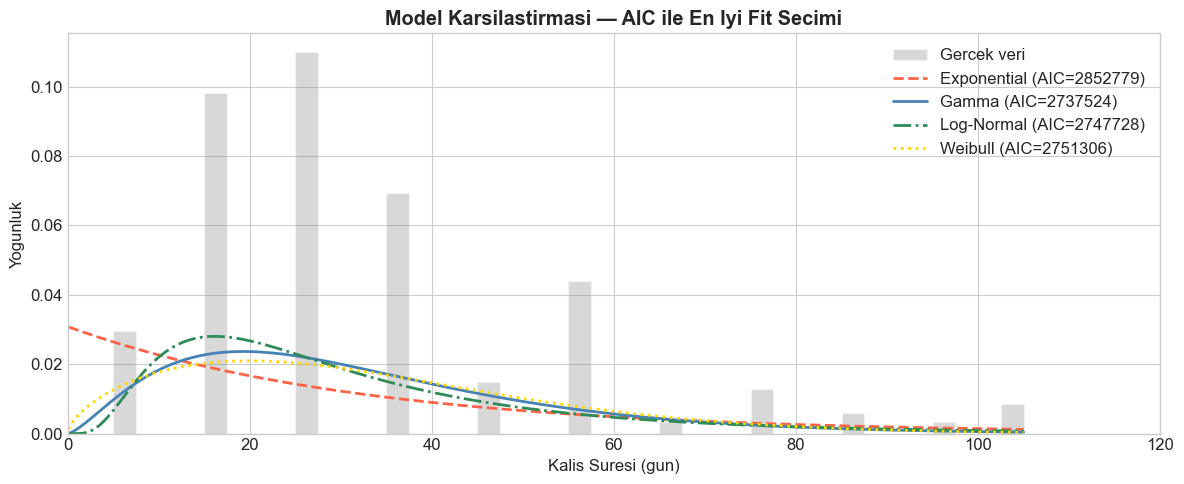

In [103]:
veri = hc['stay_gun'].values
n    = len(veri)

# Her dagilim icin MLE fit + log-likelihood
modeller = {}

# 1. Exponential
loc_e, scale_e = stats.expon.fit(veri, floc=0)
ll_e = stats.expon(loc=loc_e, scale=scale_e).logpdf(veri).sum()
modeller['Exponential'] = {'params': 1, 'logL': ll_e,
                           'paramStr': f'λ={1/scale_e:.4f}'}

# 2. Gamma
a_g, loc_g, scale_g = stats.gamma.fit(veri, floc=0)
ll_g = stats.gamma(a=a_g, loc=loc_g, scale=scale_g).logpdf(veri).sum()
modeller['Gamma'] = {'params': 2, 'logL': ll_g,
                     'paramStr': f'α={a_g:.3f}, β={scale_g:.3f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}

# 4. Weibull
c_w, loc_w, scale_w = stats.weibull_min.fit(veri, floc=0)
ll_w = stats.weibull_min(c=c_w, loc=loc_w, scale=scale_w).logpdf(veri).sum()
modeller['Weibull'] = {'params': 2, 'logL': ll_w,
                          'paramStr': f'c={c_w:.3f}, scale={scale_w:.3f}'}

# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(veri, bins=40, density=True, color='gray', alpha=0.3,
        edgecolor='white', label='Gercek veri')
x_r = np.linspace(0.1, veri.max(), 500)

dist_cizim = [
    ('Exponential', stats.expon(scale=scale_e), 'tomato',       '--'),
    ('Gamma',       stats.gamma(a=a_g, scale=scale_g), 'steelblue', '-'),
    ('Log-Normal',  stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), 'seagreen', '-.'),
    ('Weibull',     stats.weibull_min(c=c_w, loc=loc_w, scale=scale_w), 'gold', ':'),
]

for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    ax.plot(x_r, dist.pdf(x_r), color=renk, linewidth=2, linestyle=ls,
            label=f'{ad} (AIC={row["AIC"]:.0f})')

ax.set_xlim(0, 120)
ax.set_xlabel('Kalis Suresi (gun)')
ax.set_ylabel('Yogunluk')
ax.set_title('Model Karsilastirmasi — AIC ile En Iyi Fit Secimi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


[ 5.  45.5 45.5 ... 55.5 15.5 15.5]
=== Model Karsilastirmasi (n=28,516) ===
Dagilim            k         logL          AIC          BIC Parametreler
Exponential        1   -128746.86    257495.72    257503.98  λ=0.0298
Gamma              2   -124585.80    249175.60    249192.12  α=2.209, β=15.217
Log-Normal         2   -124953.37    249910.74    249927.26  μ=3.272, σ=0.734
Weibull            2   -125115.52    250235.05    250251.56  c=1.527, scale=37.516

→ En iyi AIC: Gamma  (α=2.209, β=15.217)


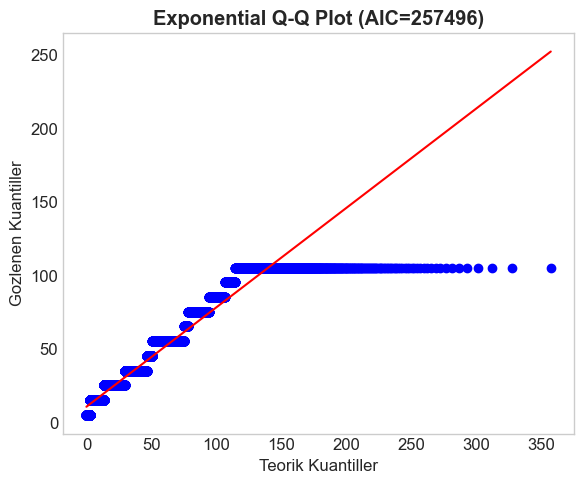

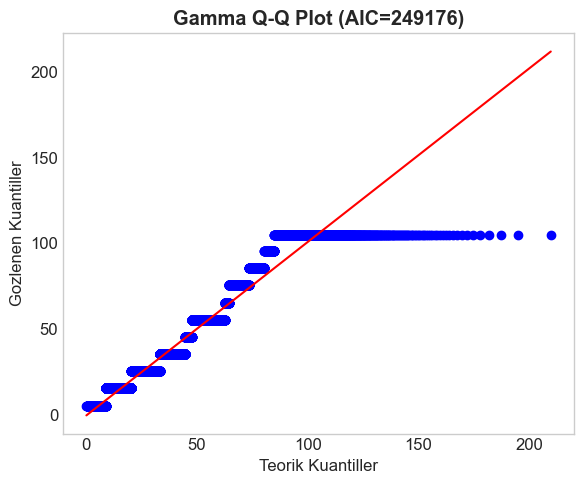

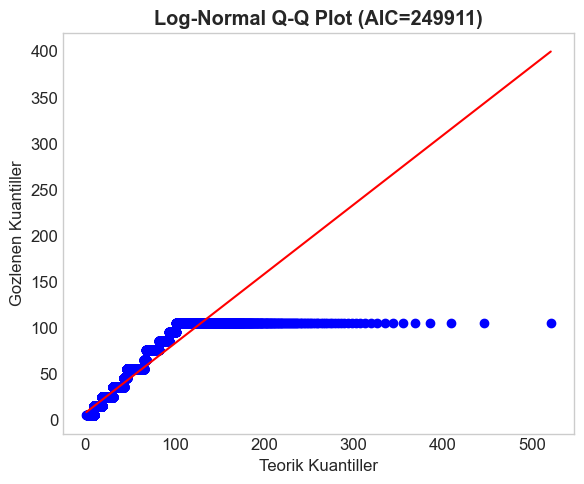

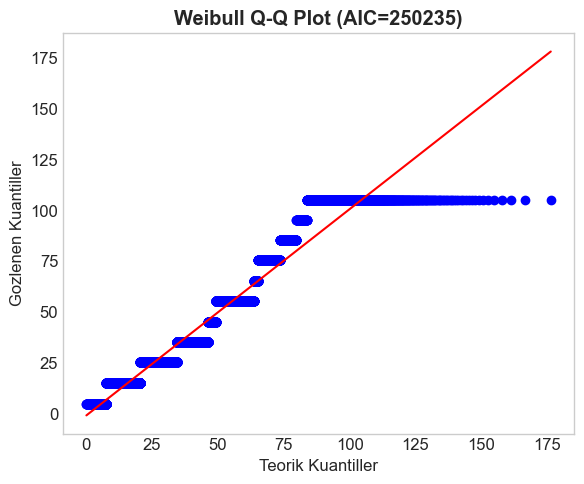

In [124]:
veri = hc[hc['Department'] == 'radiotherapy']['stay_gun'].values
print(veri)
n = len(veri)



# Her dagilim icin MLE fit + log-likelihood
modeller = {}

# 1. Exponential
loc_e, scale_e = stats.expon.fit(veri, floc=0)
ll_e = stats.expon(loc=loc_e, scale=scale_e).logpdf(veri).sum()
modeller['Exponential'] = {'params': 1, 'logL': ll_e,
                           'paramStr': f'λ={1/scale_e:.4f}'}

# 2. Gamma
a_g, loc_g, scale_g = stats.gamma.fit(veri, floc=0)
ll_g = stats.gamma(a=a_g, loc=loc_g, scale=scale_g).logpdf(veri).sum()
modeller['Gamma'] = {'params': 2, 'logL': ll_g,
                     'paramStr': f'α={a_g:.3f}, β={scale_g:.3f}'}

# 3. Log-Normal (log(X) ~ Normal)
mu_ln, sigma_ln = stats.norm.fit(np.log(veri))
ll_ln = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)).logpdf(veri).sum()
modeller['Log-Normal'] = {'params': 2, 'logL': ll_ln,
                          'paramStr': f'μ={mu_ln:.3f}, σ={sigma_ln:.3f}'}

# 4. Weibull
c_w, loc_w, scale_w = stats.weibull_min.fit(veri, floc=0)
ll_w = stats.weibull_min(c=c_w, loc=loc_w, scale=scale_w).logpdf(veri).sum()
modeller['Weibull'] = {'params': 2, 'logL': ll_w,
                          'paramStr': f'c={c_w:.3f}, scale={scale_w:.3f}'}

# AIC ve BIC hesabi
print(f'=== Model Karsilastirmasi (n={n:,}) ===')
print(f'{"Dagilim":<15} {"k":>4} {"logL":>12} {"AIC":>12} {"BIC":>12} {"Parametreler"}')
sonuclar = []
for ad, m in modeller.items():
    k   = m['params']
    ll  = m['logL']
    aic = 2*k - 2*ll
    bic = k * np.log(n) - 2*ll
    sonuclar.append({'ad': ad, 'k': k, 'logL': ll, 'AIC': aic, 'BIC': bic,
                     'params': m['paramStr']})
    print(f'{ad:<15} {k:>4} {ll:>12.2f} {aic:>12.2f} {bic:>12.2f}  {m["paramStr"]}')

en_iyi = min(sonuclar, key=lambda x: x['AIC'])
print(f'\n→ En iyi AIC: {en_iyi["ad"]}  ({en_iyi["params"]})')

# Gorsel karsilastirma (qq-plot)
for ad, dist, renk, ls in dist_cizim:
    row = next(r for r in sonuclar if r['ad']==ad)
    plt.figure(figsize=(6, 5))
    stats.probplot(veri, dist=dist, plot=plt)
    plt.title(f'{ad} Q-Q Plot (AIC={row["AIC"]:.0f})', fontweight='bold')
    plt.xlabel('Teorik Kuantiller')
    plt.ylabel('Gozlenen Kuantiller')
    plt.grid()
    plt.tight_layout()
    plt.show()


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Chan](https://probability4datascience.com) | Ch. 4.3–4.5 | Gamma ailesi teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 8–10 | Gamma ve Chi-Square |
| [Khan Academy](https://khanacademy.org) | Chi-Square tests | Test mantığı |
| [MASS package R](https://cran.r-project.org/web/packages/MASS/) | fitdistr | R'da MLE |